<a href="https://colab.research.google.com/github/iarabertopena/active-learning-for-multi-label-streams/blob/main/al_teste_treino_inicial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bibliotecas

In [1]:
%%writefile requirements.txt
numpy
pandas
scipy
matplotlib
seaborn
capymoa
psutil
rarfile

Overwriting requirements.txt


In [2]:
!pip install -r requirements.txt

### Imports

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import rarfile
import psutil
import time
import math
import os

from capymoa.classifier import (AdaptiveRandomForestClassifier)

from capymoa.evaluation import prequential_evaluation

from capymoa.drift.detectors import ADWIN

from capymoa.stream import NumpyStream
from capymoa.stream import Schema

from IPython.utils import process
from collections import deque
from datetime import datetime
from scipy.io import arff
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (hamming_loss, f1_score)

### Datasets

In [4]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Flags.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/flags"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "flags.arff")

print(dataset_path)

Mounted at /content/drive
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/flags/flags.arff


In [5]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Emotions.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/emotions"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "emotions.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/emotions/emotions.arff


In [6]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Scene.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/scene"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "scene.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/scene/scene.arff


In [7]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Yeast.arff"

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Yeast.arff


In [8]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/water-quality.arff"

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/water-quality.arff


In [9]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/SynHPGrad.arff"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/SynHPInc.arff"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/"

dataset_paths = {
    "flags": base_path + "flags/flags.arff",
    "emotions": base_path + "emotions/emotions.arff",
    "scene": base_path + "scene/scene.arff",
    #"birds": base_path + "birds/birds.arff",
    #"yeast": base_path + "Yeast.arff",
    #"water-quality": base_path + "water-quality.arff",
    #"SynHPGrad": base_path + "SynHPGrad.arff",
    #"SynHPInc": base_path + "SynHPInc.arff"
}

n_labels_dict = {
    "flags": 7,
    "emotions": 6,
    "scene": 6,
    #"birds": 19,
    #"yeast": 14,
    #"water-quality": 14,
    #"SynHPGrad": 8,
    #"SynHPInc": 8
}

In [12]:
def load_multilabel_dataset(dataset_name):

    dataset_path = dataset_paths[dataset_name]

    n_labels = n_labels_dict[dataset_name]

    # carregar arff
    data, meta = arff.loadarff(dataset_path)

    # dataframe
    df = pd.DataFrame(data)

    # converter bytes -> string/int
    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x: x.decode('utf-8')
                if isinstance(x, bytes)
                else x
            )

    # converter tudo para float
    df = df.astype(float)

    # dataset com labels no começo
    if dataset_name in ["synhpgrad", "synhpinc", "yeast"]:

        Y = df.iloc[:, :n_labels].values.astype(int)

        X = df.iloc[:, n_labels:].values

    # datasets com labels no final
    else:

        X = df.iloc[:, :-n_labels].values

        Y = df.iloc[:, -n_labels:].values.astype(int)

    return X, Y

### Métricas de avaliação

In [13]:
# métricas
metrics = {
    "f1": "Macro-F1",
    "hamming": "Hamming Loss",
    "exact_match": "Exact Match"
}

### Binary Relevance

In [14]:
class BinaryRelevance:

    def __init__(self, model_class, n_labels, schema, model_params=None):

        self.n_labels = n_labels
        self.models = []

        if model_params is None:
            model_params = {}

        for _ in range(n_labels):

            model = model_class(
                schema=schema,
                **model_params
            )

            self.models.append(model)

    # previsão
    def predict(self, x):

        predictions = []

        temp_stream = NumpyStream(
             X=np.array([x]),
             y=np.array([0])
          )

        instance = temp_stream.next_instance()

        for model in self.models:

            pred = model.predict(instance)

            if pred is None:
                pred = 0

            predictions.append(int(pred))

        return np.array(predictions)

    # probabilidades
    def predict_proba(self, x):

        probabilities = []

        temp_stream = NumpyStream(
            X=np.array([x]),
            y=np.array([0])
        )

        instance = temp_stream.next_instance()

        for model in self.models:

            proba = model.predict_proba(instance)

            if proba is None:
                proba = np.array([0.5, 0.5])

            probabilities.append(proba)

        return probabilities

    # treino
    def train(self, x, y, label_mask=None):

        # se não tem máscara, assume que todos os rótulos estão disponíveis
        if label_mask is None:
            label_mask = [True] * self.n_labels

        if len(label_mask) != self.n_labels:
            raise ValueError("label_mask deve ter tamanho n_labels")

        for j, model in enumerate(self.models):

            # treina apenas os rótulos observados
            if label_mask[j]:

              temp_stream = NumpyStream(
                  X=np.array([x]),
                  y=np.array([y[j]])
              )

              instance = temp_stream.next_instance()

              model.train(instance)

### Active Learning

In [15]:
class ActiveLearningStrategy:

    def __init__(self):

        self.total_seen = 0
        self.total_queried = 0

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):
        raise NotImplementedError

#### Random

In [16]:
class RandomSampling(ActiveLearningStrategy):

    def __init__(self, budget):

        super().__init__()

        self.budget = budget

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        # orçamento esgotado
        if self.total_queried >= self.budget_limit:
            return False

        if np.random.rand() < self.budget:

            self.total_queried += 1

            return True

        return False

#### Uncertainty sampling

In [17]:
def compute_uncertainty(probabilities):
    uncertainties = []

    for proba in probabilities:
        # Least Confidence
        confidence = np.max(proba)
        uncertainty = 1 - confidence
        uncertainties.append(uncertainty)

    #result = np.mean(uncertainties)
    result = np.max(uncertainties)

    return result

In [18]:
class UncertaintySampling(ActiveLearningStrategy):

    def __init__(self, threshold, budget):

        super().__init__()

        self.threshold = threshold
        self.budget = budget

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        # orçamento esgotado
        if self.total_queried >= self.budget_limit:
            return False

        #print(probabilities)
        uncertainty = compute_uncertainty(probabilities)

        if uncertainty >= self.threshold:

            self.total_queried += 1

            return True

        return False

#### Query-by-committee

In [19]:
committee_configs = [
    {
        "model_class": AdaptiveRandomForestClassifier,
        "model_params": {"random_seed": 1}
    },
    {
        "model_class": AdaptiveRandomForestClassifier,
        "model_params": {"random_seed": 2}
    },
    {
        "model_class": AdaptiveRandomForestClassifier,
        "model_params": {"random_seed": 3}
    },
    {
        "model_class": AdaptiveRandomForestClassifier,
        "model_params": {"random_seed": 4}
    },
    {
        "model_class": AdaptiveRandomForestClassifier,
        "model_params": {"random_seed": 5}
    }
]

In [20]:
class Committee:

    def __init__(self, committee_configs, n_labels, schema):

        self.models = []

        for config in committee_configs:

            br_model = BinaryRelevance(
                model_class=config["model_class"],
                n_labels=n_labels,
                schema=schema,
                model_params=config.get("model_params", {})
            )

            self.models.append(br_model)

    def predict_all(self, x):

        predictions = []

        for model in self.models:

            predictions.append(
                model.predict(x)
            )

        return np.array(predictions)

    def predict_proba_all(self, x):

        probabilities = []

        for model in self.models:

            probabilities.append(
                model.predict_proba(x)
            )

        return probabilities

    def train(self, x, y, label_mask=None):

        for model in self.models:

            model.train(x, y, label_mask=label_mask)

In [21]:
def compute_vote_entropy(predictions):

    entropies = []

    n_members = predictions.shape[0]

    for label in range(predictions.shape[1]):

        votes = predictions[:, label]

        counts = np.bincount(
            votes,
            minlength=2
        )

        probs = counts / n_members

        probs = probs[probs > 0]

        entropy = -np.sum(
            probs * np.log2(probs)
        )

        entropies.append(entropy)

    return np.mean(entropies)

In [22]:
class QueryByCommittee(ActiveLearningStrategy):

    def __init__(self, threshold, budget, warmup):

        super().__init__()

        self.threshold = threshold
        self.budget = budget
        self.warmup = warmup

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        # orçamento esgotado
        if self.total_queried >= self.budget_limit:
            return False

        # warm-up
        if self.total_seen <= self.warmup:

            self.total_queried += 1
            return True

        if committee_predictions is None:
            return False

        disagreement = compute_vote_entropy(committee_predictions)

        #print(f"Seen={self.total_seen} | "f"Disagreement={disagreement:.4f}")

        if disagreement >= self.threshold:

            self.total_queried += 1
            return True

        return False

#### Bounds

##### Lower Bound -> sem consultas (budget = 0%)

In [23]:
class NoQuery(ActiveLearningStrategy):

    def __init__(self):

        super().__init__()

        self.budget = 0

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        return False

##### Upper Bound -> aprendizado totalmente supervisionado (budget = 100%)

In [24]:
class FullSupervision(ActiveLearningStrategy):

    def __init__(self):

        super().__init__()

        self.budget = 1.0

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1
        self.total_queried += 1

        return True

### Pool-based Active Learning

In [25]:
class Pool:

    def __init__(self, pool_size):

        self.pool_size = pool_size
        self.instances = []

    def add(
        self,
        x,
        y,
        y_pred,
        probabilities,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.instances.append({
            "x": x,
            "y": y,
            "y_pred": y_pred,
            "probabilities": probabilities,
            "committee_predictions": committee_predictions,
            "committee_probabilities": committee_probabilities
        })

    def is_full(self):

        return len(self.instances) >= self.pool_size

    def clear(self):

        self.instances = []

    def __len__(self):

        return len(self.instances)

In [26]:
class PoolBasedStrategy(ActiveLearningStrategy):

    def __init__(self, budget):

        super().__init__()

        self.budget = budget

    def query_pool(self, pool):

        raise NotImplementedError

#### Random

In [27]:
class PoolRandomSampling(PoolBasedStrategy):

    def __init__(self, budget):

        super().__init__(budget)

    def query_pool(self, pool):

        remaining_budget = self.budget_limit - self.total_queried

        if remaining_budget <= 0:
            return []

        k = min(
            self.pool_budget,
            remaining_budget,
            len(pool.instances)
        )

        indices = np.random.choice(
            len(pool.instances),
            size=k,
            replace=False
        )

        self.total_seen += len(pool.instances)
        self.total_queried += len(indices)

        return indices

#### Uncertainty sampling

In [28]:
class PoolUncertaintySampling(PoolBasedStrategy):

    def __init__(self, budget):

        super().__init__(budget)

    def query_pool(self, pool):

        remaining_budget = self.budget_limit - self.total_queried

        if remaining_budget <= 0:
            return []

        scores = []

        for inst in pool.instances:

            u = compute_uncertainty(
                inst["probabilities"]
            )

            scores.append(u)

        order = np.argsort(scores)[::-1]

        k = min(
            self.pool_budget,
            remaining_budget,
            len(order)
        )

        selected = order[:k]

        self.total_seen += len(pool.instances)
        self.total_queried += len(selected)

        return selected

#### Query-by-committee

In [29]:
class PoolQueryByCommittee(PoolBasedStrategy):

    def __init__(self, budget):

        super().__init__(budget)

    def query_pool(self, pool):

        remaining_budget = (
            self.budget_limit - self.total_queried
        )

        if remaining_budget <= 0:
            return []

        scores = []

        for inst in pool.instances:

            disagreement = compute_vote_entropy(
                inst["committee_predictions"]
            )

            scores.append(disagreement)

        # ordenar da maior discordância para a menor
        order = np.argsort(scores)[::-1]

        k = min(
            self.pool_budget,
            remaining_budget,
            len(order)
        )

        selected = order[:k]

        self.total_seen += len(pool.instances)
        self.total_queried += len(selected)

        return selected

### Cálculo de budget por pool

In [30]:
def compute_pool_budget(strategy, n_instances, pool_size):

    strategy.budget_limit = int(strategy.budget * n_instances)

    n_pools = math.ceil(n_instances / pool_size)

    strategy.pool_budget = max(1, math.ceil(strategy.budget_limit / n_pools))

    print(f"Budget total: {strategy.budget_limit}")
    print(f"Number of pools: {n_pools}")
    print(f"Budget per pool: {strategy.pool_budget}")

### Salvar resultados

In [31]:
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RESULTS_DIR = Path(
    f"/disk2/iara/projetos/active_learning_multilabel/results/run_{RUN_TIMESTAMP}"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def save_result(
    dataset,
    strategy,
    budget=None,
    train_fraction=None,
    mode="online",
    results=None,
    output_dir=RESULTS_DIR
):

    # Salva um experimento em um CSV.
    # Se o arquivo já existir, adiciona uma nova linha.

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    output_file = output_dir / f"{mode}_results.csv"

    row = {
        "Dataset": dataset,
        "Strategy": strategy,
        "Budget": budget,
        "train_fraction": train_fraction,
        **{k: v for k, v in results.items() if k != "History"}
    }

    df = pd.DataFrame([row])

    if output_file.exists():
        df.to_csv(output_file, mode="a", header=False, index=False)
    else:
        df.to_csv(output_file, index=False)

In [32]:
def save_figure(filename, output_dir=RESULTS_DIR):

    # Salva a figura atual do matplotlib dentro da pasta figures.

    output_dir = Path(output_dir)

    figures_dir = output_dir / "figures"
    figures_dir.mkdir(exist_ok=True)

    plt.savefig(
        figures_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

### Loop principal

In [33]:
def run_experiment(dataset_name, strategy, model_class, train_fraction=0.30, mode="online", pool_size=None):

    print(f"Dataset: {dataset_name}")

    # carregar dados
    X, Y = load_multilabel_dataset(dataset_name)

    # split (para teste inicial)
    X_train, X_stream, Y_train, Y_stream = train_test_split(
        X,
        Y,
        test_size=1 - train_fraction,
        shuffle=False
    )

    print(f"Train: {len(X_train)} | "f"Stream: {len(X_stream)}")

    n = len(X_stream)

    # cálculo do orçamento
    if hasattr(strategy, "budget"):
        if mode == "pool":
            compute_pool_budget(strategy, n_instances=n, pool_size=pool_size)

        else:
            strategy.budget_limit = int(strategy.budget * n)

            print(f"Budget total: {strategy.budget_limit}")

    # checkpoints em %
    checkpoints = [
        max(1, round(n * pct / 100))
        for pct in range(10, 101, 10)
    ]

    strategy.total_seen = 0
    strategy.total_queried = 0

    # schema
    dummy_X = np.zeros((1, X.shape[1]))
    dummy_y = np.zeros(1)

    stream = NumpyStream(
        X=dummy_X,
        y=dummy_y
    )

    schema = stream.get_schema()

    # modelo principal
    model = BinaryRelevance(
        model_class=model_class,
        n_labels=Y.shape[1],
        schema=schema
    )

    # detector de drift
    adwin = ADWIN()

    drift_points = []

    # comitê para QBC
    committee = None

    if isinstance(strategy, (QueryByCommittee, PoolQueryByCommittee)):
        committee = Committee(
            committee_configs=committee_configs,
            n_labels=Y.shape[1],
            schema=schema
        )

    uses_probabilities = isinstance(
        strategy,
        (UncertaintySampling, PoolUncertaintySampling)
    )

    uses_committee = isinstance(
        strategy,
        (QueryByCommittee, PoolQueryByCommittee)
    )

    # treinamento inicial (30% do dataset)
    for i in range(len(X_train)):
        model.train(
            X_train[i],
            Y_train[i]
        )

        if committee is not None:
            committee.train(
                X_train[i],
                Y_train[i]
            )

    # tempo inicial
    start_time = time.time()

    # memória inicial
    process = psutil.Process(os.getpid())
    memory_before = process.memory_info().rss / 1024**2

    # métricas
    hamming_scores = []
    exact_match_scores = []
    f1_scores = []

    # histórico opara gráficos
    history = {
        "progress": [],
        "hamming": [],
        "exact_match": [],
        "f1": [],
        "queries": [],
        "evaluated": []
    }

    # pool (apenas para modo pool)
    if mode == "pool":
        pool = Pool(pool_size)

    # loop prequential (70% do dataset)
    for i in range(len(X_stream)):
        x = X_stream[i]
        y = Y_stream[i]

        # previsão do modelo principal
        y_pred = model.predict(x)

        # probabilidades do modelo principal
        probs = None

        if uses_probabilities:
            probs = model.predict_proba(x)

        # previsões do comitê
        committee_predictions = None

        if uses_committee:
            committee_predictions = committee.predict_all(x)

        # métricas
        ham = hamming_loss(y, y_pred)

        exact = int(np.array_equal(y, y_pred))

        f1 = f1_score(
            y,
            y_pred,
            average="macro",
            zero_division=0
        )

        hamming_scores.append(ham)
        exact_match_scores.append(exact)
        f1_scores.append(f1)

        # detector de drift
        adwin.add_element(ham)

        if adwin.detected_change():
            drift_points.append(i)

        # salvar histórico nos checkpoints
        if (i + 1) in checkpoints:
            history["progress"].append(round(100 * (i + 1) / n))

            if len(hamming_scores) > 0:
                history["hamming"].append(np.mean(hamming_scores))
                history["exact_match"].append(np.mean(exact_match_scores))
                history["f1"].append(np.mean(f1_scores))

            else:
                history["hamming"].append(np.nan)
                history["exact_match"].append(np.nan)
                history["f1"].append(np.nan)

            history["queries"].append(strategy.total_queried)
            history["evaluated"].append(len(hamming_scores))

        # Active Learning
        # ONLINE
        if mode == "online":
            queried = strategy.query(
                x=x,
                y_pred=y_pred,
                probabilities=probs,
                committee_predictions=committee_predictions,
                committee_probabilities=None
            )

            if queried:
                model.train(x, y)

                if committee is not None:
                    committee.train(x, y)

        # POOL
        else:
            pool.add(
                x=x,
                y=y,
                y_pred=y_pred,
                probabilities=probs,
                committee_predictions=committee_predictions
            )

            if pool.is_full():
                selected = strategy.query_pool(pool)

                for idx in selected:
                    inst = pool.instances[idx]

                    model.train(inst["x"], inst["y"])

                    if committee is not None:
                        committee.train(inst["x"], inst["y"])

                pool.clear()

    if mode == "pool" and len(pool) > 0:
        selected = strategy.query_pool(pool)

        for idx in selected:
            inst = pool.instances[idx]

            model.train(inst["x"], inst["y"])

            if committee is not None:
                committee.train(inst["x"], inst["y"])

    # tempo final
    end_time = time.time()
    execution_time = end_time - start_time

    # memória final
    memory_after = process.memory_info().rss / 1024**2

    memory_usage = max(
        0,
        memory_after - memory_before
    )

    # consultas por segundo
    queries_per_second = (
        strategy.total_queried / execution_time
        if execution_time > 0
        else 0
    )

    # proporção de instâncias consultadas
    query_rate = (
        strategy.total_queried / strategy.total_seen
        if strategy.total_seen > 0
        else 0
    )

    # resultados finais
    results = {
      "Hamming Loss": np.mean(hamming_scores),
      "Exact Match": np.mean(exact_match_scores),
      "F1-score": np.mean(f1_scores),
      "Execution Time (s)": execution_time,
      "Memory Usage (MB)": memory_usage,
      "Queried Instances": strategy.total_queried,
      "Queries per Second": queries_per_second,
      "Query Rate": query_rate,
      "Drift Points": drift_points,
      "Number of Drifts": len(drift_points),
      "History": history
  }

    print(results)

    return results

### Testes

In [ ]:
all_results_online = {}

budgets = [0.10]#, 0.20, 0.30, 0.40, 0.50]
train_fractions = [0.05, 0.10, 0.20, 0.30]

for dataset_name in dataset_paths.keys():

    all_results_online[dataset_name] = {}

    for train_fraction in train_fractions:

        print(f"Dataset: {dataset_name}")
        print(f"Treino inicial: {train_fraction:.0%}")

        # Estratégias sem budget
        fixed_strategies = {
            "NoQuery": NoQuery(),
            "FullSupervision": FullSupervision()
        }

        for strategy_name, strategy in fixed_strategies.items():

            print(f"\nStrategy: {strategy_name}")

            results = run_experiment(
                dataset_name,
                strategy,
                model_class=AdaptiveRandomForestClassifier,
                train_fraction=train_fraction,
                mode="online"
            )

            key = f"{strategy_name}_{int(train_fraction*100)}%"
            all_results_online[dataset_name][key] = results

            save_result(
                dataset=dataset_name,
                strategy=strategy_name,
                budget=None,
                train_fraction=train_fraction,
                mode="online",
                results=results
            )

        # Estratégias com budget
        for budget in budgets:

            strategies = {
                "Random": RandomSampling(budget=budget),
                "Uncertainty": UncertaintySampling(
                    threshold=0.30,
                    budget=budget
                ),
                "QBC": QueryByCommittee(
                    threshold=0.10,
                    budget=budget,
                    warmup=0
                )
            }

            for strategy_name, strategy in strategies.items():

                print(f"\nStrategy: {strategy_name} | Budget: {int(budget*100)}%")

                results = run_experiment(
                    dataset_name,
                    strategy,
                    model_class=AdaptiveRandomForestClassifier,
                    train_fraction=train_fraction,
                    mode="online"
                )

                key = (
                    f"{strategy_name}_"
                    f"{int(budget*100)}%_"
                    f"train{int(train_fraction*100)}%"
                )

                all_results_online[dataset_name][key] = results

                save_result(
                    dataset=dataset_name,
                    strategy=strategy_name,
                    budget=budget,
                    train_fraction=train_fraction,
                    mode="online",
                    results=results
                )

Dataset: flags
Treino inicial: 5%

Strategy: NoQuery
Dataset: flags
Train: 9 | Stream: 185
Budget total: 0
{'Hamming Loss': np.float64(0.3451737451737451), 'Exact Match': np.float64(0.016216216216216217), 'F1-score': np.float64(0.6323782223782223), 'Execution Time (s)': 2.545334577560425, 'Memory Usage (MB)': 0, 'Queried Instances': 0, 'Queries per Second': 0.0, 'Query Rate': 0.0, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.3333333333333333), np.float64(0.3088803088803088), np.float64(0.3086734693877551), np.float64(0.332046332046332), np.float64(0.3400621118012422), np.float64(0.35006435006435005), np.float64(0.345054945054945), np.float64(0.3503861003861003), np.float64(0.3511187607573149), np.float64(0.3451737451737451)], 'exact_match': [np.float64(0.0), np.float64(0.02702702702702703), np.float64(0.03571428571428571), np.float64(0.02702702702702703), np.float64(0.021739130434782608), np.float

In [ ]:
all_results_pool = {}

budgets = [0.10]#, 0.20, 0.30, 0.40, 0.50]
train_fractions = [0.05, 0.10, 0.20, 0.30]

pool_size = 100

for dataset_name in dataset_paths.keys():

    all_results_pool[dataset_name] = {}

    for train_fraction in train_fractions:

        print("\n" + "=" * 70)
        print(f"Dataset: {dataset_name}")
        print(f"Treino inicial: {train_fraction:.0%}")
        print("=" * 70)

        for budget in budgets:

            strategies = {
                "PoolRandom": PoolRandomSampling(budget=budget),
                "PoolUncertainty": PoolUncertaintySampling(budget=budget),
                "PoolQBC": PoolQueryByCommittee(budget=budget)
            }

            for strategy_name, strategy in strategies.items():

                print(f"\nStrategy: {strategy_name} | Budget: {int(budget*100)}%")

                results = run_experiment(
                    dataset_name,
                    strategy,
                    model_class=AdaptiveRandomForestClassifier,
                    train_fraction=train_fraction,
                    mode="pool",
                    pool_size=pool_size
                )

                key = (
                    f"{strategy_name}_"
                    f"{int(budget*100)}%_"
                    f"train{int(train_fraction*100)}%"
                )

                all_results_pool[dataset_name][key] = results

                save_result(
                    dataset=dataset_name,
                    strategy=strategy_name,
                    budget=budget,
                    train_fraction=train_fraction,
                    mode="pool",
                    results=results
                )


Dataset: flags
Treino inicial: 5%

Strategy: PoolRandom | Budget: 10%
Dataset: flags
Train: 9 | Stream: 185
Budget total: 18
Number of pools: 2
Budget per pool: 9
{'Hamming Loss': np.float64(0.32432432432432423), 'Exact Match': np.float64(0.08648648648648649), 'F1-score': np.float64(0.6557029757029756), 'Execution Time (s)': 1.8211729526519775, 'Memory Usage (MB)': 0.03125, 'Queried Instances': 18, 'Queries per Second': 9.883740022488553, 'Query Rate': 0.0972972972972973, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.3333333333333333), np.float64(0.3088803088803088), np.float64(0.3086734693877551), np.float64(0.332046332046332), np.float64(0.3400621118012422), np.float64(0.34362934362934366), np.float64(0.32087912087912085), np.float64(0.3243243243243243), np.float64(0.3261617900172117), np.float64(0.32432432432432423)], 'exact_match': [np.float64(0.0), np.float64(0.02702702702702703), np.float64(

In [36]:
all_results_online = {}

budgets = [0.10]#, 0.20, 0.30, 0.40, 0.50]
train_fractions = [0.50, 0.80]

for dataset_name in dataset_paths.keys():

    all_results_online[dataset_name] = {}

    for train_fraction in train_fractions:

        print("\n" + "=" * 70)
        print(f"Dataset: {dataset_name}")
        print(f"Treino inicial: {train_fraction:.0%}")
        print("\n" + "=" * 70)

        # Estratégias sem budget
        fixed_strategies = {
            "NoQuery": NoQuery(),
            "FullSupervision": FullSupervision()
        }

        for strategy_name, strategy in fixed_strategies.items():

            print(f"\nStrategy: {strategy_name}")

            results = run_experiment(
                dataset_name,
                strategy,
                model_class=AdaptiveRandomForestClassifier,
                train_fraction=train_fraction,
                mode="online"
            )

            key = f"{strategy_name}_{int(train_fraction*100)}%"
            all_results_online[dataset_name][key] = results

            save_result(
                dataset=dataset_name,
                strategy=strategy_name,
                budget=None,
                train_fraction=train_fraction,
                mode="online",
                results=results
            )

        # Estratégias com budget
        for budget in budgets:

            strategies = {
                "Random": RandomSampling(budget=budget),
                "Uncertainty": UncertaintySampling(
                    threshold=0.30,
                    budget=budget
                ),
                "QBC": QueryByCommittee(
                    threshold=0.10,
                    budget=budget,
                    warmup=0
                )
            }

            for strategy_name, strategy in strategies.items():

                print(f"\nStrategy: {strategy_name} | Budget: {int(budget*100)}%")

                results = run_experiment(
                    dataset_name,
                    strategy,
                    model_class=AdaptiveRandomForestClassifier,
                    train_fraction=train_fraction,
                    mode="online"
                )

                key = (
                    f"{strategy_name}_"
                    f"{int(budget*100)}%_"
                    f"train{int(train_fraction*100)}%"
                )

                all_results_online[dataset_name][key] = results

                save_result(
                    dataset=dataset_name,
                    strategy=strategy_name,
                    budget=budget,
                    train_fraction=train_fraction,
                    mode="online",
                    results=results
                )


Dataset: flags
Treino inicial: 50%


Strategy: NoQuery
Dataset: flags
Train: 97 | Stream: 97
Budget total: 0
{'Hamming Loss': np.float64(0.26509572901325473), 'Exact Match': np.float64(0.10309278350515463), 'F1-score': np.float64(0.7097897234495173), 'Execution Time (s)': 1.0855932235717773, 'Memory Usage (MB)': 0.44140625, 'Queried Instances': 0, 'Queries per Second': 0.0, 'Query Rate': 0.0, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 49, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.22857142857142856), np.float64(0.2781954887218045), np.float64(0.2758620689655173), np.float64(0.2527472527472527), np.float64(0.24107142857142852), np.float64(0.24630541871921177), np.float64(0.2563025210084033), np.float64(0.26007326007326004), np.float64(0.25615763546798026), np.float64(0.26509572901325473)], 'exact_match': [np.float64(0.1), np.float64(0.10526315789473684), np.float64(0.06896551724137931), np.float64(0.10256410256410256), np.float64(0.166666666

In [37]:
all_results_pool = {}

budgets = [0.10]#, 0.20, 0.30, 0.40, 0.50]
train_fractions = [0.50, 0.80]

pool_size = 100

for dataset_name in dataset_paths.keys():

    all_results_pool[dataset_name] = {}

    for train_fraction in train_fractions:

        print("\n" + "=" * 70)
        print(f"Dataset: {dataset_name}")
        print(f"Treino inicial: {train_fraction:.0%}")
        print("=" * 70)

        for budget in budgets:

            strategies = {
                "PoolRandom": PoolRandomSampling(budget=budget),
                "PoolUncertainty": PoolUncertaintySampling(budget=budget),
                "PoolQBC": PoolQueryByCommittee(budget=budget)
            }

            for strategy_name, strategy in strategies.items():

                print(f"\nStrategy: {strategy_name} | Budget: {int(budget*100)}%")

                results = run_experiment(
                    dataset_name,
                    strategy,
                    model_class=AdaptiveRandomForestClassifier,
                    train_fraction=train_fraction,
                    mode="pool",
                    pool_size=pool_size
                )

                key = (
                    f"{strategy_name}_"
                    f"{int(budget*100)}%_"
                    f"train{int(train_fraction*100)}%"
                )

                all_results_pool[dataset_name][key] = results

                save_result(
                    dataset=dataset_name,
                    strategy=strategy_name,
                    budget=budget,
                    train_fraction=train_fraction,
                    mode="pool",
                    results=results
                )


Dataset: flags
Treino inicial: 50%

Strategy: PoolRandom | Budget: 10%
Dataset: flags
Train: 97 | Stream: 97
Budget total: 9
Number of pools: 1
Budget per pool: 9
{'Hamming Loss': np.float64(0.26509572901325473), 'Exact Match': np.float64(0.10309278350515463), 'F1-score': np.float64(0.7097897234495173), 'Execution Time (s)': 2.05057954788208, 'Memory Usage (MB)': 0.00390625, 'Queried Instances': 9, 'Queries per Second': 4.389003103681375, 'Query Rate': 0.09278350515463918, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 49, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.22857142857142856), np.float64(0.2781954887218045), np.float64(0.2758620689655173), np.float64(0.2527472527472527), np.float64(0.24107142857142852), np.float64(0.24630541871921177), np.float64(0.2563025210084033), np.float64(0.26007326007326004), np.float64(0.25615763546798026), np.float64(0.26509572901325473)], 'exact_match': [np.float64(0.1), np.float64(0.10526315789473684), np.flo

### Teste com 0%

In [38]:
def run_experiment(dataset_name, strategy, model_class, train_fraction=0.30, mode="online", pool_size=None):

    print(f"Dataset: {dataset_name}")

    # carregar dados
    X, Y = load_multilabel_dataset(dataset_name)

    if train_fraction == 0.0:
        # 0% treino inicial → tudo vai para a stream
        X_train = X[:0]
        Y_train = Y[:0]

        X_stream = X
        Y_stream = Y

    elif train_fraction == 1.0:
        # 100% treino inicial → tudo vai para o treino
        X_train = X
        Y_train = Y

        X_stream = X[:0]
        Y_stream = Y[:0]

    else:
        # comportamento original para todas as outras frações
        X_train, X_stream, Y_train, Y_stream = train_test_split(
            X,
            Y,
            test_size=1 - train_fraction,
            shuffle=False
        )

    print(f"Train: {len(X_train)} | "f"Stream: {len(X_stream)}")

    n = len(X_stream)

    # cálculo do orçamento
    if hasattr(strategy, "budget"):
        if mode == "pool":
            compute_pool_budget(strategy, n_instances=n, pool_size=pool_size)

        else:
            strategy.budget_limit = int(strategy.budget * n)

            print(f"Budget total: {strategy.budget_limit}")

    # checkpoints em %
    checkpoints = [
        max(1, round(n * pct / 100))
        for pct in range(10, 101, 10)
    ]

    strategy.total_seen = 0
    strategy.total_queried = 0

    # schema
    dummy_X = np.zeros((1, X.shape[1]))
    dummy_y = np.zeros(1)

    stream = NumpyStream(
        X=dummy_X,
        y=dummy_y
    )

    schema = stream.get_schema()

    # modelo principal
    model = BinaryRelevance(
        model_class=model_class,
        n_labels=Y.shape[1],
        schema=schema
    )

    # detector de drift
    adwin = ADWIN()

    drift_points = []

    # comitê para QBC
    committee = None

    if isinstance(strategy, (QueryByCommittee, PoolQueryByCommittee)):
        committee = Committee(
            committee_configs=committee_configs,
            n_labels=Y.shape[1],
            schema=schema
        )

    uses_probabilities = isinstance(
        strategy,
        (UncertaintySampling, PoolUncertaintySampling)
    )

    uses_committee = isinstance(
        strategy,
        (QueryByCommittee, PoolQueryByCommittee)
    )

    # treinamento inicial (30% do dataset)
    for i in range(len(X_train)):
        model.train(
            X_train[i],
            Y_train[i]
        )

        if committee is not None:
            committee.train(
                X_train[i],
                Y_train[i]
            )

    # tempo inicial
    start_time = time.time()

    # memória inicial
    process = psutil.Process(os.getpid())
    memory_before = process.memory_info().rss / 1024**2

    # métricas
    hamming_scores = []
    exact_match_scores = []
    f1_scores = []

    # histórico opara gráficos
    history = {
        "progress": [],
        "hamming": [],
        "exact_match": [],
        "f1": [],
        "queries": [],
        "evaluated": []
    }

    # pool (apenas para modo pool)
    if mode == "pool":
        pool = Pool(pool_size)

    # loop prequential (70% do dataset)
    for i in range(len(X_stream)):
        x = X_stream[i]
        y = Y_stream[i]

        # previsão do modelo principal
        y_pred = model.predict(x)

        # probabilidades do modelo principal
        probs = None

        if uses_probabilities:
            probs = model.predict_proba(x)

        # previsões do comitê
        committee_predictions = None

        if uses_committee:
            committee_predictions = committee.predict_all(x)

        # métricas
        ham = hamming_loss(y, y_pred)

        exact = int(np.array_equal(y, y_pred))

        f1 = f1_score(
            y,
            y_pred,
            average="macro",
            zero_division=0
        )

        hamming_scores.append(ham)
        exact_match_scores.append(exact)
        f1_scores.append(f1)

        # detector de drift
        adwin.add_element(ham)

        if adwin.detected_change():
            drift_points.append(i)

        # salvar histórico nos checkpoints
        if (i + 1) in checkpoints:
            history["progress"].append(round(100 * (i + 1) / n))

            if len(hamming_scores) > 0:
                history["hamming"].append(np.mean(hamming_scores))
                history["exact_match"].append(np.mean(exact_match_scores))
                history["f1"].append(np.mean(f1_scores))

            else:
                history["hamming"].append(np.nan)
                history["exact_match"].append(np.nan)
                history["f1"].append(np.nan)

            history["queries"].append(strategy.total_queried)
            history["evaluated"].append(len(hamming_scores))

        # Active Learning
        # ONLINE
        if mode == "online":
            queried = strategy.query(
                x=x,
                y_pred=y_pred,
                probabilities=probs,
                committee_predictions=committee_predictions,
                committee_probabilities=None
            )

            if queried:
                model.train(x, y)

                if committee is not None:
                    committee.train(x, y)

        # POOL
        else:
            pool.add(
                x=x,
                y=y,
                y_pred=y_pred,
                probabilities=probs,
                committee_predictions=committee_predictions
            )

            if pool.is_full():
                selected = strategy.query_pool(pool)

                for idx in selected:
                    inst = pool.instances[idx]

                    model.train(inst["x"], inst["y"])

                    if committee is not None:
                        committee.train(inst["x"], inst["y"])

                pool.clear()

    if mode == "pool" and len(pool) > 0:
        selected = strategy.query_pool(pool)

        for idx in selected:
            inst = pool.instances[idx]

            model.train(inst["x"], inst["y"])

            if committee is not None:
                committee.train(inst["x"], inst["y"])

    # tempo final
    end_time = time.time()
    execution_time = end_time - start_time

    # memória final
    memory_after = process.memory_info().rss / 1024**2

    memory_usage = max(
        0,
        memory_after - memory_before
    )

    # consultas por segundo
    queries_per_second = (
        strategy.total_queried / execution_time
        if execution_time > 0
        else 0
    )

    # proporção de instâncias consultadas
    query_rate = (
        strategy.total_queried / strategy.total_seen
        if strategy.total_seen > 0
        else 0
    )

    # resultados finais
    results = {
      "Hamming Loss": np.mean(hamming_scores),
      "Exact Match": np.mean(exact_match_scores),
      "F1-score": np.mean(f1_scores),
      "Execution Time (s)": execution_time,
      "Memory Usage (MB)": memory_usage,
      "Queried Instances": strategy.total_queried,
      "Queries per Second": queries_per_second,
      "Query Rate": query_rate,
      "Drift Points": drift_points,
      "Number of Drifts": len(drift_points),
      "History": history
  }

    print(results)

    return results

In [39]:
all_results_online = {}

budgets = [0.10]#, 0.20, 0.30, 0.40, 0.50]
train_fractions = [0.0]

for dataset_name in dataset_paths.keys():

    all_results_online[dataset_name] = {}

    for train_fraction in train_fractions:

        print("\n" + "=" * 70)
        print(f"Dataset: {dataset_name}")
        print(f"Treino inicial: {train_fraction:.0%}")
        print("\n" + "=" * 70)

        # Estratégias sem budget
        fixed_strategies = {
            "NoQuery": NoQuery(),
            "FullSupervision": FullSupervision()
        }

        for strategy_name, strategy in fixed_strategies.items():

            print(f"\nStrategy: {strategy_name}")

            results = run_experiment(
                dataset_name,
                strategy,
                model_class=AdaptiveRandomForestClassifier,
                train_fraction=train_fraction,
                mode="online"
            )

            key = f"{strategy_name}_{int(train_fraction*100)}%"
            all_results_online[dataset_name][key] = results

            save_result(
                dataset=dataset_name,
                strategy=strategy_name,
                budget=None,
                train_fraction=train_fraction,
                mode="online",
                results=results
            )

        # Estratégias com budget
        for budget in budgets:

            strategies = {
                "Random": RandomSampling(budget=budget),
                "Uncertainty": UncertaintySampling(
                    threshold=0.30,
                    budget=budget
                ),
                "QBC": QueryByCommittee(
                    threshold=0.10,
                    budget=budget,
                    warmup=0
                )
            }

            for strategy_name, strategy in strategies.items():

                print(f"\nStrategy: {strategy_name} | Budget: {int(budget*100)}%")

                results = run_experiment(
                    dataset_name,
                    strategy,
                    model_class=AdaptiveRandomForestClassifier,
                    train_fraction=train_fraction,
                    mode="online"
                )

                key = (
                    f"{strategy_name}_"
                    f"{int(budget*100)}%_"
                    f"train{int(train_fraction*100)}%"
                )

                all_results_online[dataset_name][key] = results

                save_result(
                    dataset=dataset_name,
                    strategy=strategy_name,
                    budget=budget,
                    train_fraction=train_fraction,
                    mode="online",
                    results=results
                )


Dataset: flags
Treino inicial: 0%


Strategy: NoQuery
Dataset: flags
Train: 0 | Stream: 194
Budget total: 0
{'Hamming Loss': np.float64(0.4845360824742268), 'Exact Match': np.float64(0.0), 'F1-score': np.float64(0.33078815514382526), 'Execution Time (s)': 1.0397508144378662, 'Memory Usage (MB)': 0.0234375, 'Queried Instances': 0, 'Queries per Second': 0.0, 'Query Rate': 0.0, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.4661654135338346), np.float64(0.5054945054945055), np.float64(0.49999999999999994), np.float64(0.48901098901098894), np.float64(0.4845360824742268), np.float64(0.47413793103448276), np.float64(0.4747899159663864), np.float64(0.47373271889400914), np.float64(0.4775510204081633), np.float64(0.4845360824742268)], 'exact_match': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.fl

In [40]:
all_results_pool = {}

budgets = [0.10]#, 0.20, 0.30, 0.40, 0.50]
train_fractions = [0.0]

pool_size = 100

for dataset_name in dataset_paths.keys():

    all_results_pool[dataset_name] = {}

    for train_fraction in train_fractions:

        print("\n" + "=" * 70)
        print(f"Dataset: {dataset_name}")
        print(f"Treino inicial: {train_fraction:.0%}")
        print("=" * 70)

        for budget in budgets:

            strategies = {
                "PoolRandom": PoolRandomSampling(budget=budget),
                "PoolUncertainty": PoolUncertaintySampling(budget=budget),
                "PoolQBC": PoolQueryByCommittee(budget=budget)
            }

            for strategy_name, strategy in strategies.items():

                print(f"\nStrategy: {strategy_name} | Budget: {int(budget*100)}%")

                results = run_experiment(
                    dataset_name,
                    strategy,
                    model_class=AdaptiveRandomForestClassifier,
                    train_fraction=train_fraction,
                    mode="pool",
                    pool_size=pool_size
                )

                key = (
                    f"{strategy_name}_"
                    f"{int(budget*100)}%_"
                    f"train{int(train_fraction*100)}%"
                )

                all_results_pool[dataset_name][key] = results

                save_result(
                    dataset=dataset_name,
                    strategy=strategy_name,
                    budget=budget,
                    train_fraction=train_fraction,
                    mode="pool",
                    results=results
                )


Dataset: flags
Treino inicial: 0%

Strategy: PoolRandom | Budget: 10%
Dataset: flags
Train: 0 | Stream: 194
Budget total: 19
Number of pools: 2
Budget per pool: 10
{'Hamming Loss': np.float64(0.39837997054491897), 'Exact Match': np.float64(0.061855670103092786), 'F1-score': np.float64(0.48674165181897144), 'Execution Time (s)': 3.3845834732055664, 'Memory Usage (MB)': 28.33203125, 'Queried Instances': 19, 'Queries per Second': 5.613689291582148, 'Query Rate': 0.0979381443298969, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.4661654135338346), np.float64(0.5054945054945055), np.float64(0.49999999999999994), np.float64(0.48901098901098894), np.float64(0.4845360824742268), np.float64(0.46551724137931033), np.float64(0.4422268907563025), np.float64(0.42396313364055294), np.float64(0.4089795918367346), np.float64(0.39837997054491897)], 'exact_match': [np.float64(0.0), np.float64(0.0), np.float64(0.0), 

### Gráficos Online

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"

df = pd.read_csv(ARQUIVO, header=1)

print(df.head())
print(df.shape)
print(df.columns.tolist())

  Dataset         Strategy Treino Inicial Budget  Hamming Loss  Exact Match  \
0   flags          NoQuery             0%     0%      0.484536     0.000000   
1   flags  FullSupervision             0%   100%      0.293814     0.072165   
2   flags           Random             0%    10%      0.349043     0.051546   
3   flags      Uncertainty             0%    10%      0.372607     0.020619   
4   flags              QBC             0%    10%      0.484536     0.000000   

   F1-score  Execution Time (s)  Memory Usage (MB)  Queried Instances  \
0  0.330788            1.039751           0.023438                  0   
1  0.677101           10.555913           0.019531                194   
2  0.604369            2.142218           0.000000                 19   
3  0.577960            2.378924           0.003906                 19   
4  0.330788            4.053439           0.000000                  0   

   Queries/s  Query Rate  Number of Drifts  
0   0.000000    0.000000                 

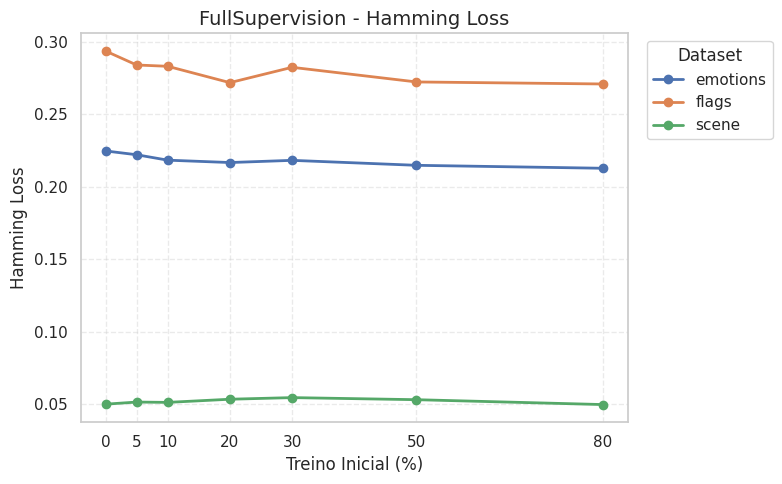

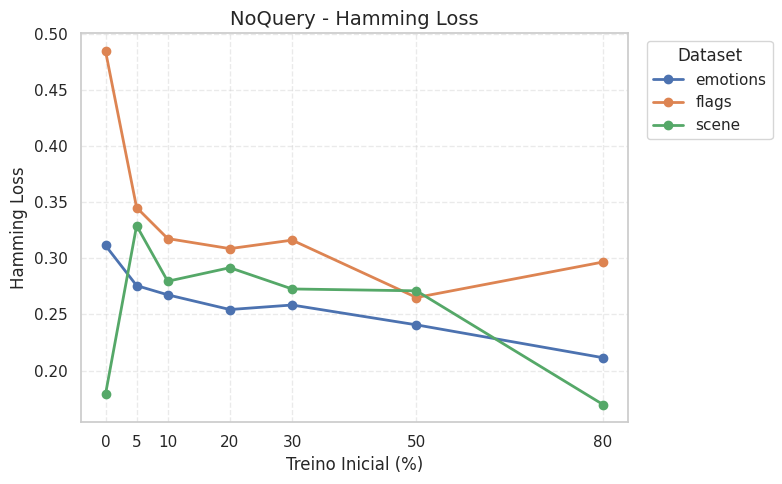

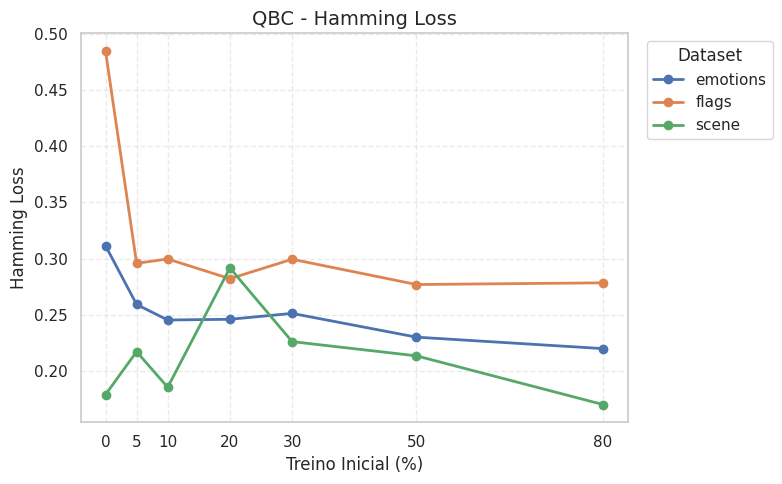

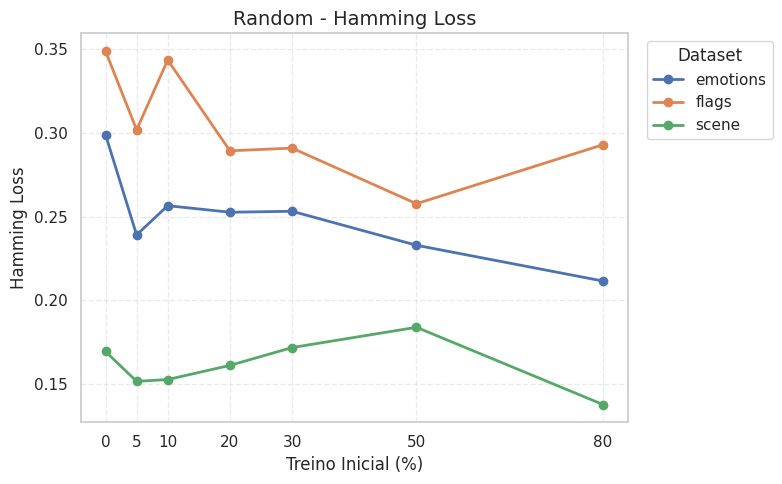

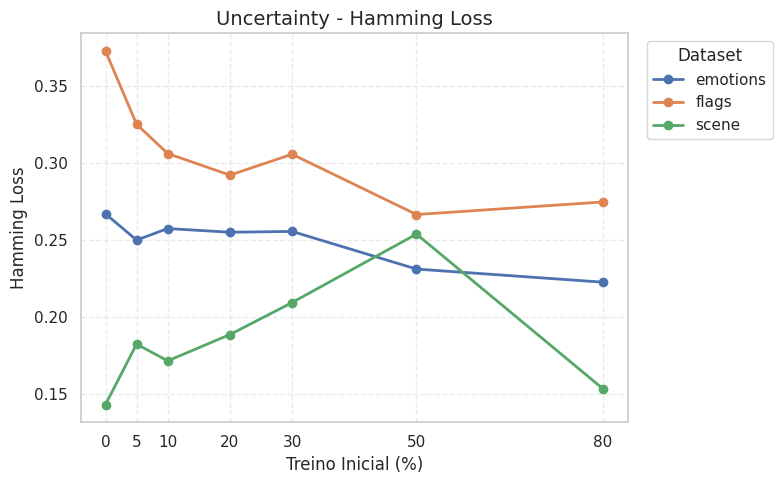

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# CONFIGURAÇÕES
# ==========================

ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "Hamming Loss"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)

# Limpa nomes das colunas
df.columns = df.columns.str.strip()

# Converte o treino inicial para número
df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

# Ordena os dados
df = df.sort_values(["Strategy", "Dataset", "Treino Inicial"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    plt.figure(figsize=(8,5))

    # Uma linha para cada dataset
    for dataset in sorted(dados["Dataset"].unique()):

        aux = dados[dados["Dataset"] == dataset]

        plt.plot(
            aux["Treino Inicial"],
            aux[METRICA],
            marker="o",
            linewidth=2,
            markersize=6,
            label=dataset
        )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(sorted(df["Treino Inicial"].unique()))

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

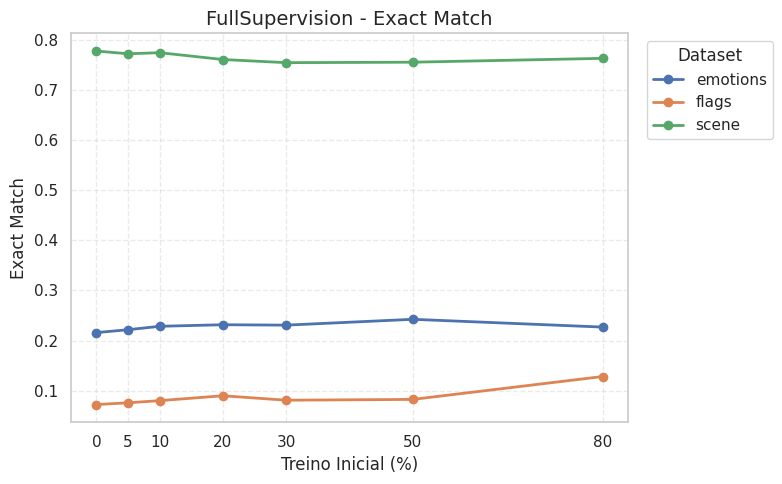

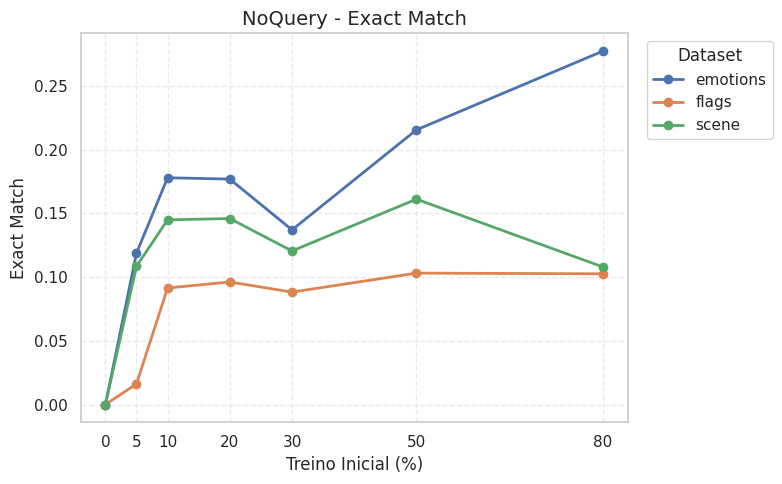

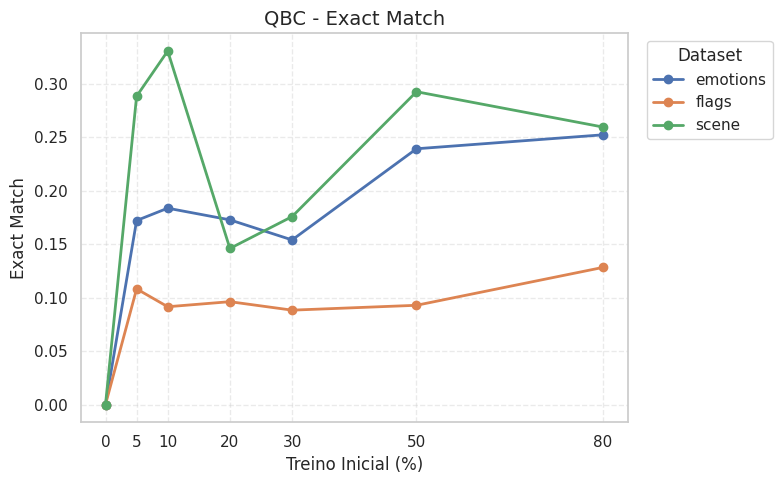

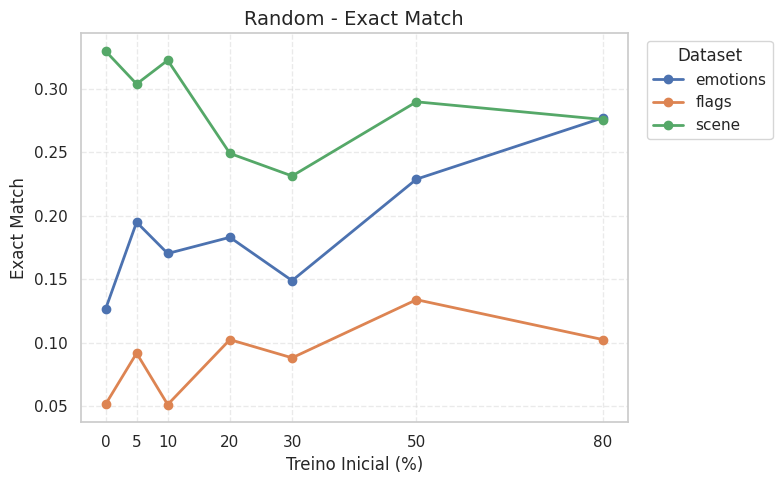

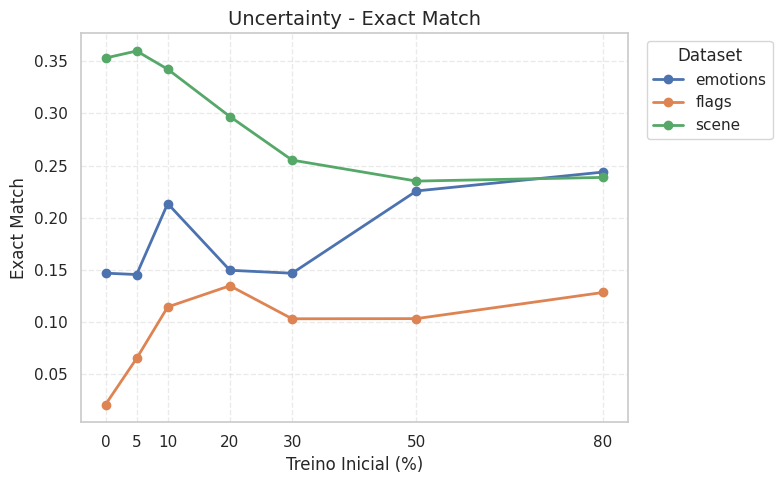

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# CONFIGURAÇÕES
# ==========================

ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "Exact Match"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)

# Limpa nomes das colunas
df.columns = df.columns.str.strip()

# Converte o treino inicial para número
df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

# Ordena os dados
df = df.sort_values(["Strategy", "Dataset", "Treino Inicial"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    plt.figure(figsize=(8,5))

    # Uma linha para cada dataset
    for dataset in sorted(dados["Dataset"].unique()):

        aux = dados[dados["Dataset"] == dataset]

        plt.plot(
            aux["Treino Inicial"],
            aux[METRICA],
            marker="o",
            linewidth=2,
            markersize=6,
            label=dataset
        )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(sorted(df["Treino Inicial"].unique()))

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

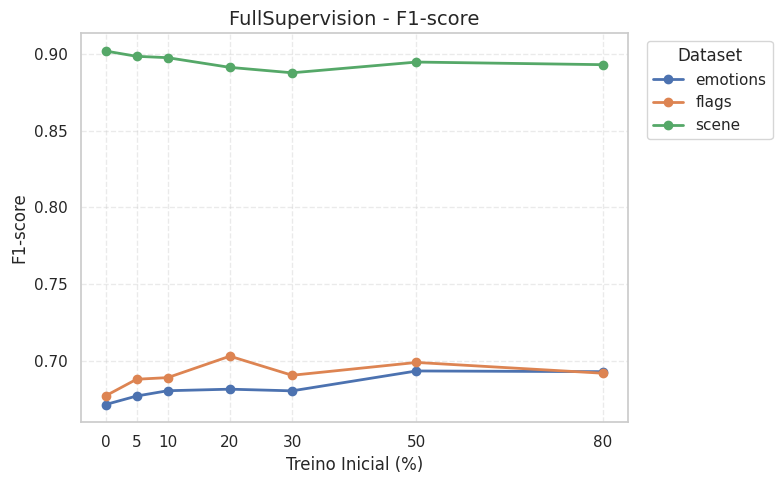

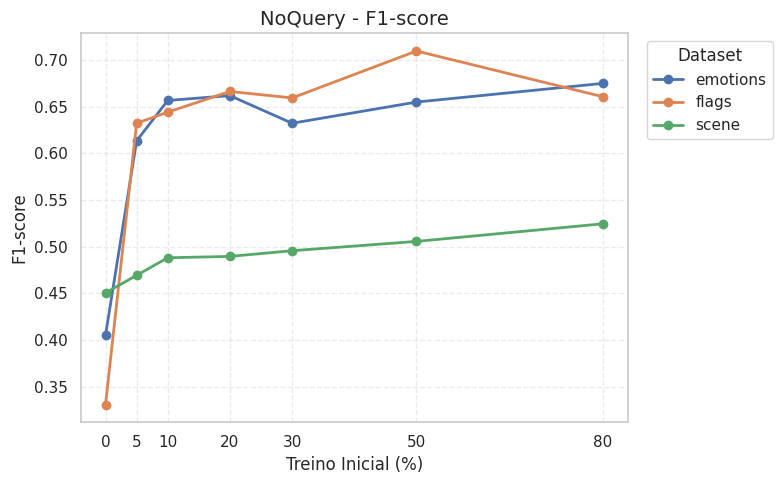

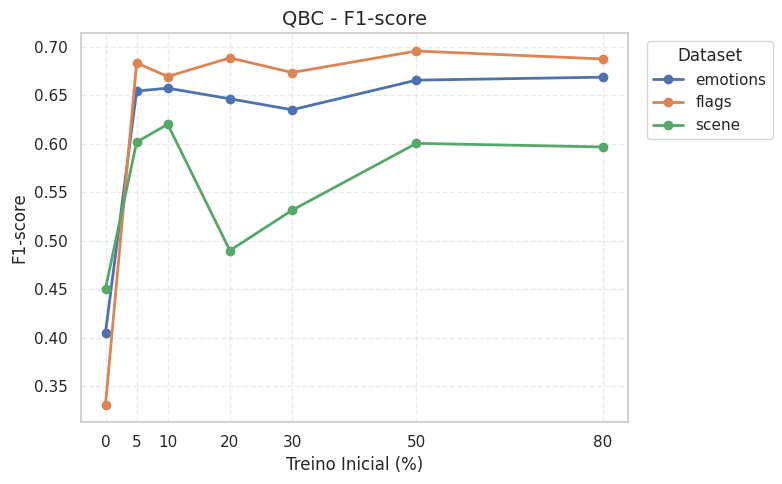

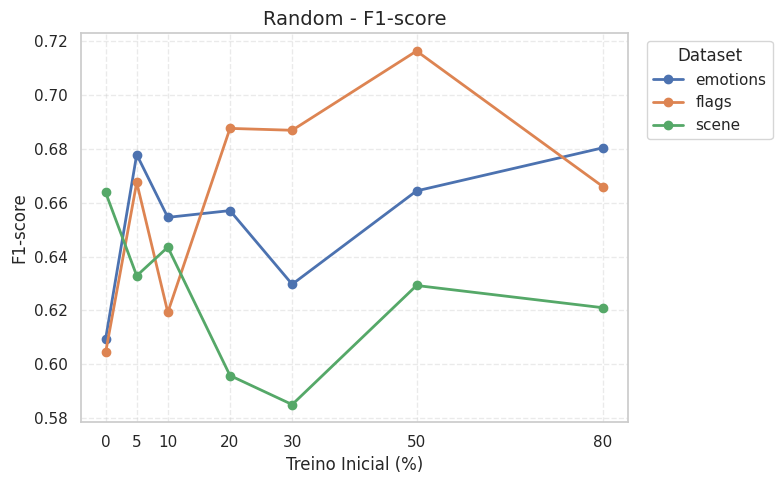

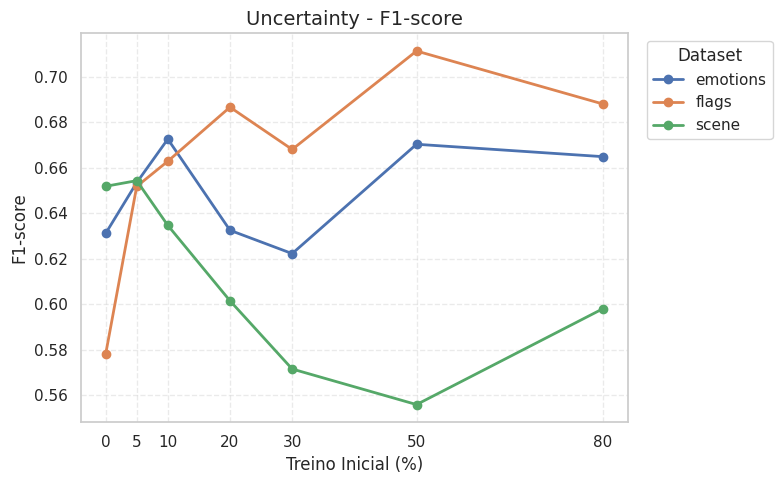

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# CONFIGURAÇÕES
# ==========================

ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "F1-score"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)

# Limpa nomes das colunas
df.columns = df.columns.str.strip()

# Converte o treino inicial para número
df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

# Ordena os dados
df = df.sort_values(["Strategy", "Dataset", "Treino Inicial"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    plt.figure(figsize=(8,5))

    # Uma linha para cada dataset
    for dataset in sorted(dados["Dataset"].unique()):

        aux = dados[dados["Dataset"] == dataset]

        plt.plot(
            aux["Treino Inicial"],
            aux[METRICA],
            marker="o",
            linewidth=2,
            markersize=6,
            label=dataset
        )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(sorted(df["Treino Inicial"].unique()))

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

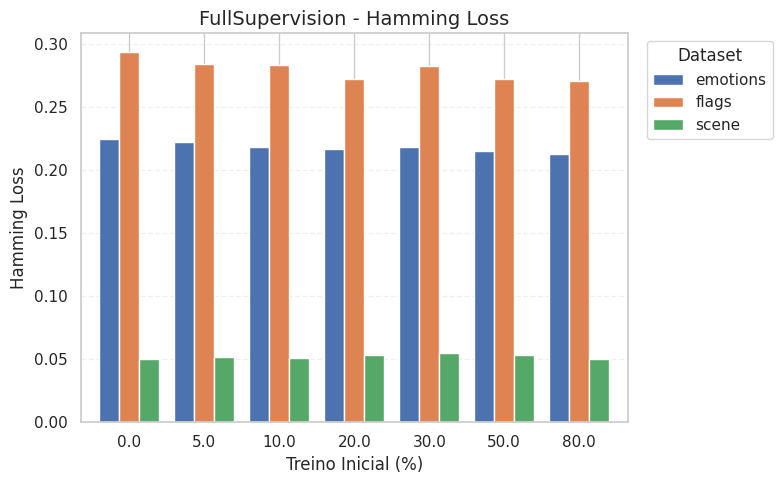

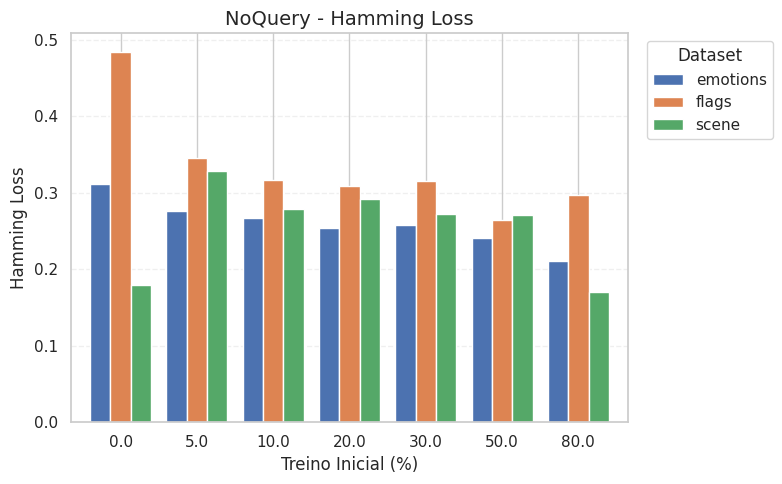

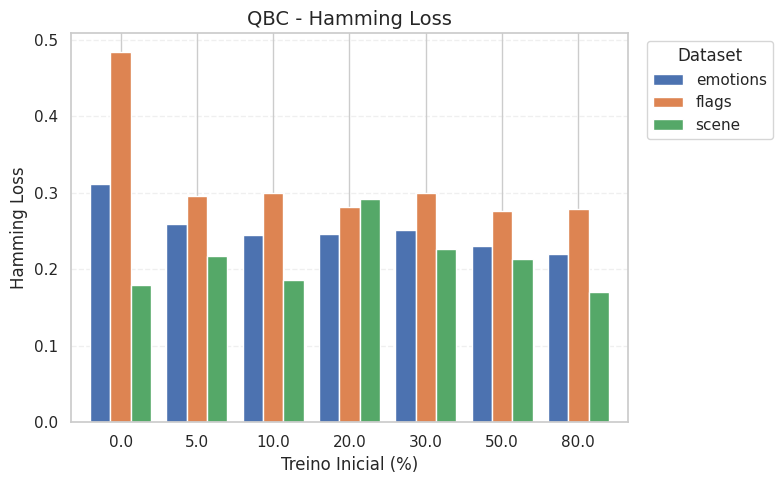

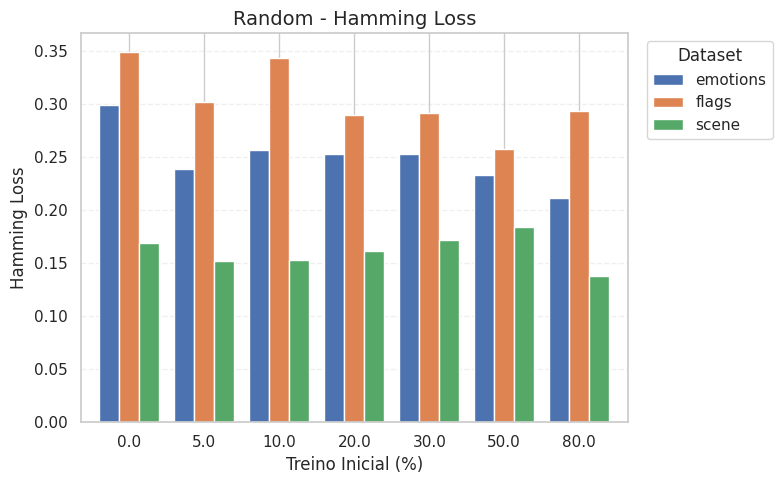

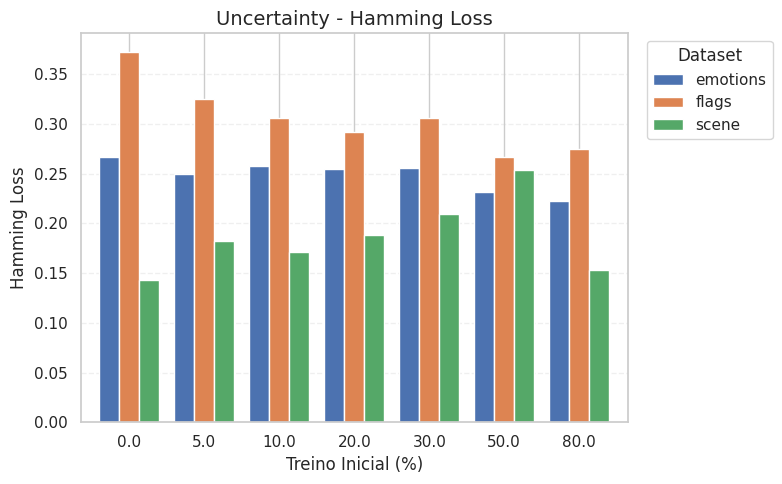

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# CONFIG=========
ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "Hamming Loss"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)
df.columns = df.columns.str.strip()

df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

df = df.sort_values(["Strategy", "Treino Inicial", "Dataset"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    tabela = dados.pivot(
        index="Treino Inicial",
        columns="Dataset",
        values=METRICA
    )

    ax = tabela.plot(
        kind="bar",
        figsize=(8,5),
        width=0.8
    )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(rotation=0)

    plt.grid(axis="y", linestyle="--", alpha=0.3)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}_bar.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

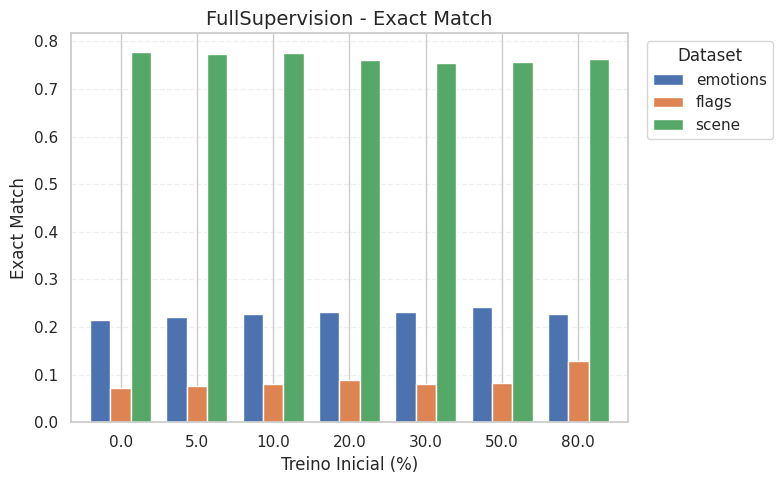

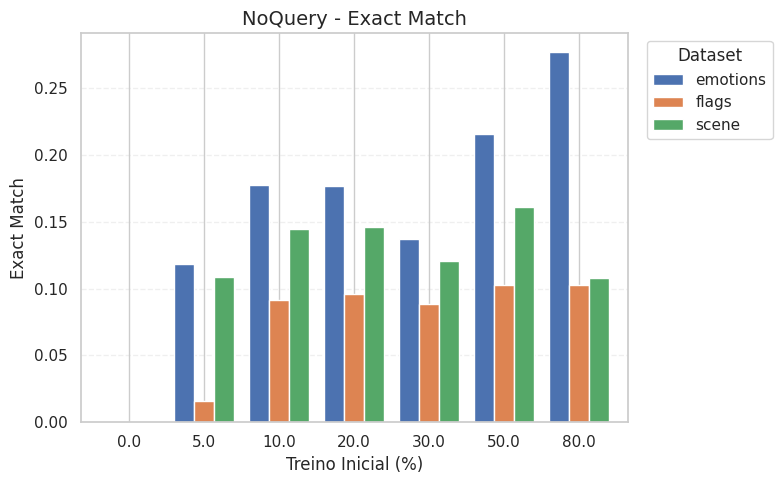

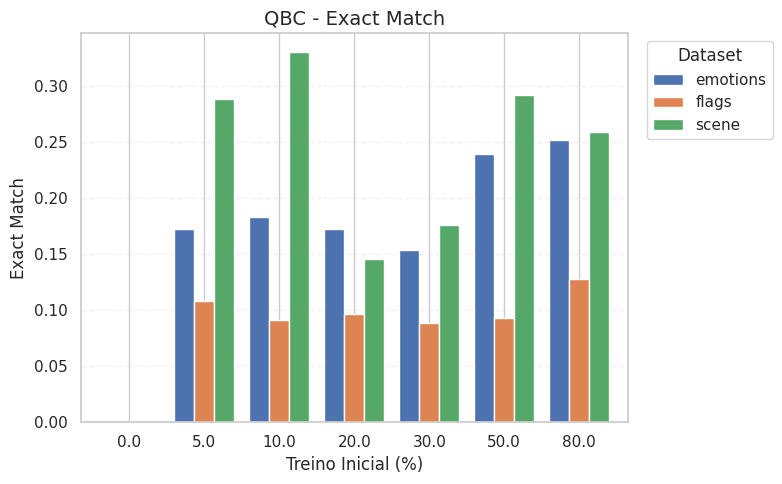

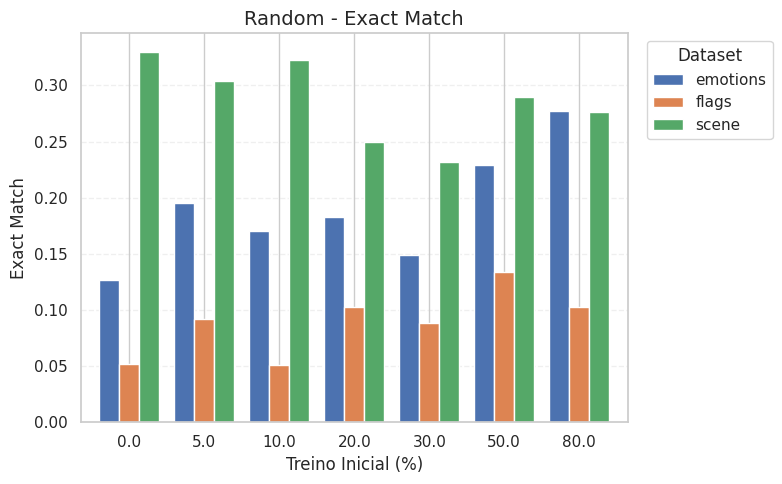

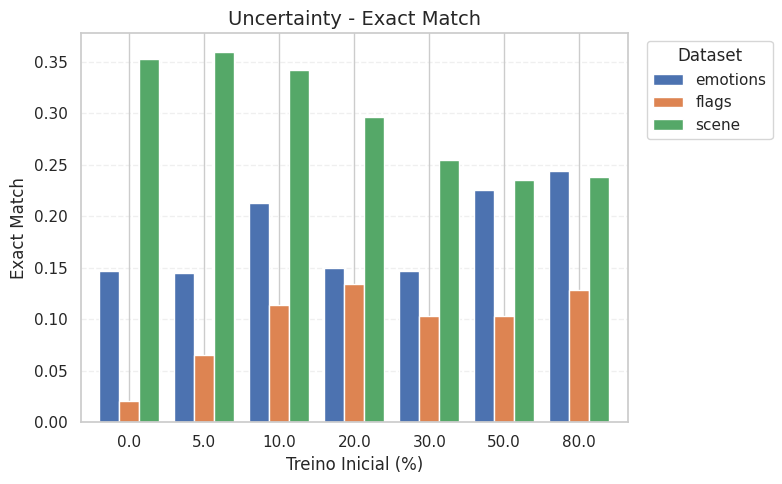

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# CONFIG=========
ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "Exact Match"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)
df.columns = df.columns.str.strip()

df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

df = df.sort_values(["Strategy", "Treino Inicial", "Dataset"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    tabela = dados.pivot(
        index="Treino Inicial",
        columns="Dataset",
        values=METRICA
    )

    ax = tabela.plot(
        kind="bar",
        figsize=(8,5),
        width=0.8
    )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(rotation=0)

    plt.grid(axis="y", linestyle="--", alpha=0.3)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}_bar.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

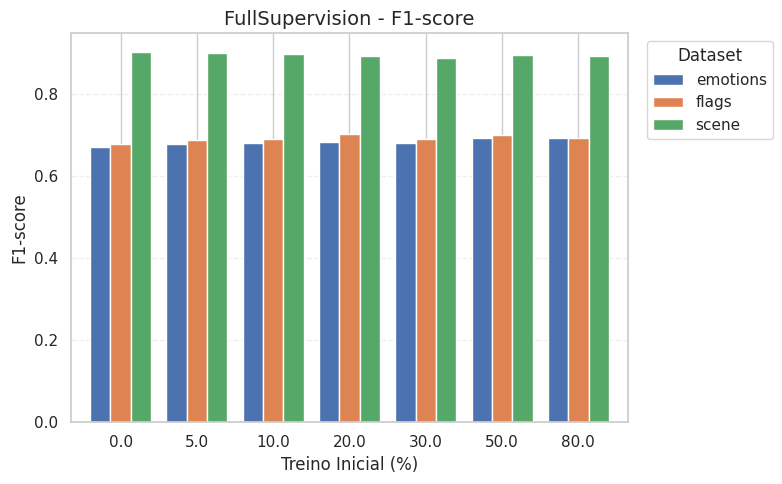

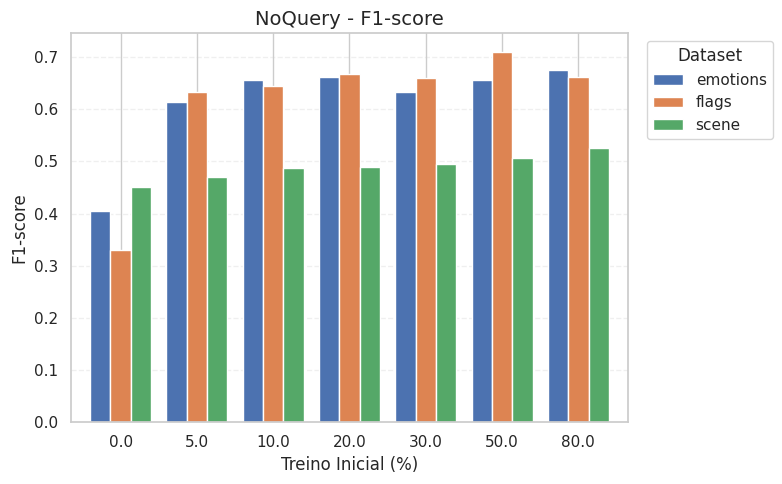

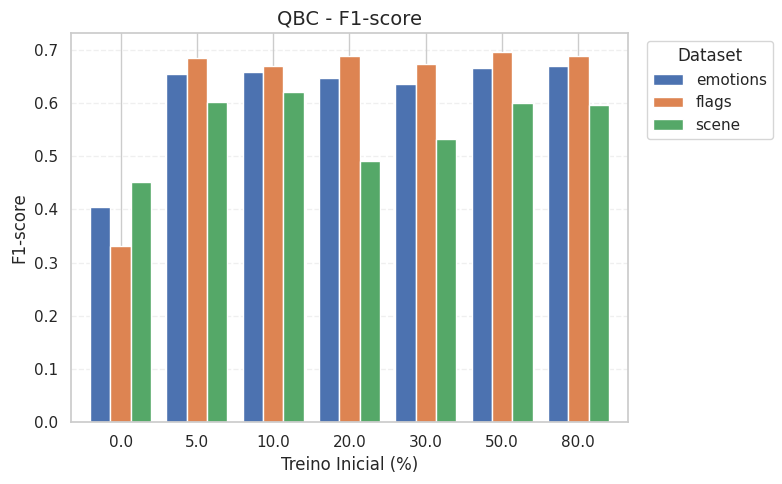

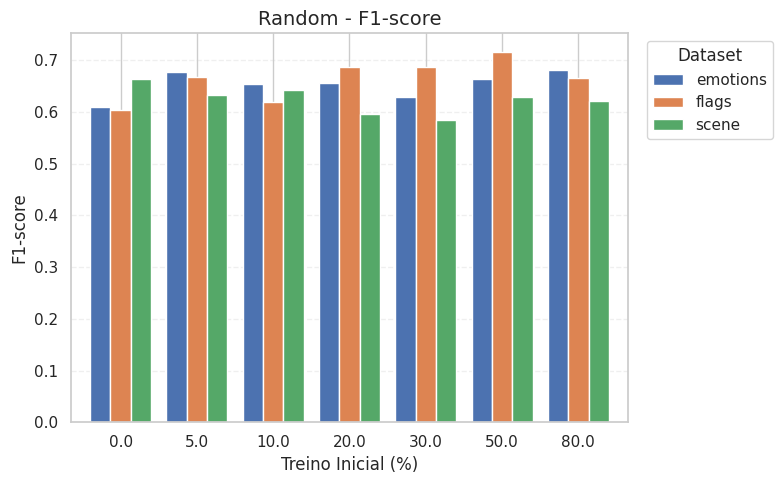

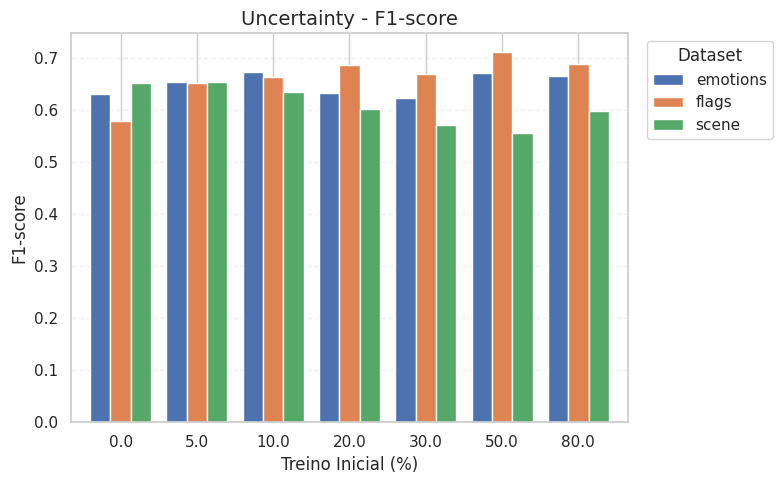

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# CONFIG=========
ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "F1-score"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)
df.columns = df.columns.str.strip()

df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

df = df.sort_values(["Strategy", "Treino Inicial", "Dataset"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    tabela = dados.pivot(
        index="Treino Inicial",
        columns="Dataset",
        values=METRICA
    )

    ax = tabela.plot(
        kind="bar",
        figsize=(8,5),
        width=0.8
    )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(rotation=0)

    plt.grid(axis="y", linestyle="--", alpha=0.3)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}_bar.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

### Gráficos Pool

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ARQUIVO = "/content/Resultados-AL-Treino_Inicial-POOL - Sheet.csv"

df = pd.read_csv(ARQUIVO, header=1)

print(df.head())
print(df.shape)
print(df.columns.tolist())

  Dataset         Strategy Treino Inicial Budget  Hamming Loss  Exact Match  \
0   flags       PoolRandom             0%    10%      0.398380     0.061856   
1   flags  PoolUncertainty             0%    10%      0.388807     0.082474   
2   flags          PoolQBC             0%    10%      0.388807     0.082474   
3   flags       PoolRandom             5%    10%      0.324324     0.086486   
4   flags  PoolUncertainty             5%    10%      0.328958     0.021622   

   F1-score  Execution Time (s)  Memory Usage (MB)  Queried Instances  \
0  0.486742            3.384583          28.332031                 19   
1  0.504636            4.140147         221.187500                 19   
2  0.504636           11.812242         654.003906                 19   
3  0.655703            1.821173           0.031250                 18   
4  0.650813            2.077662           0.117188                 18   

   Queries/s  Query Rate  Number of Drifts  
0   5.613689    0.097938                 

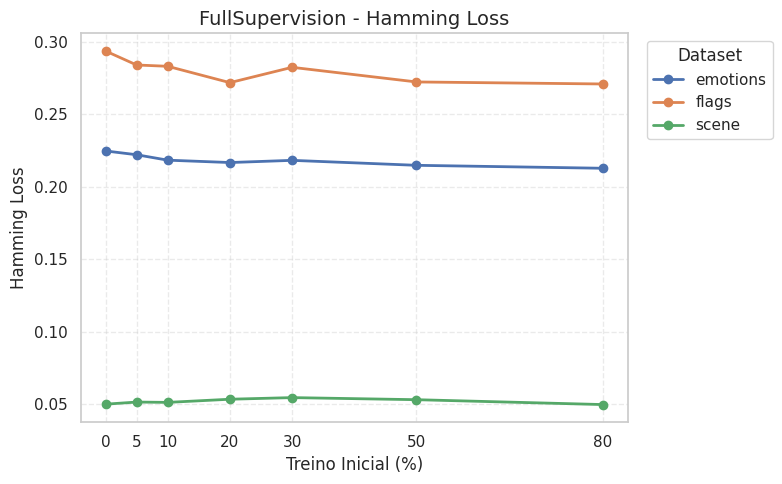

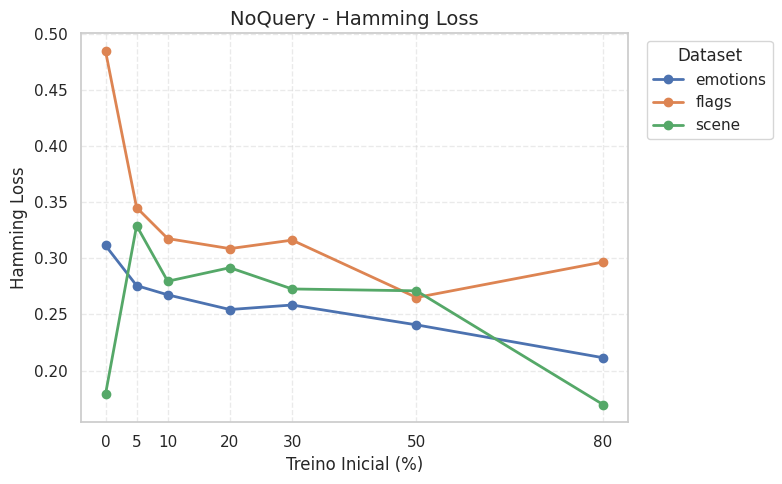

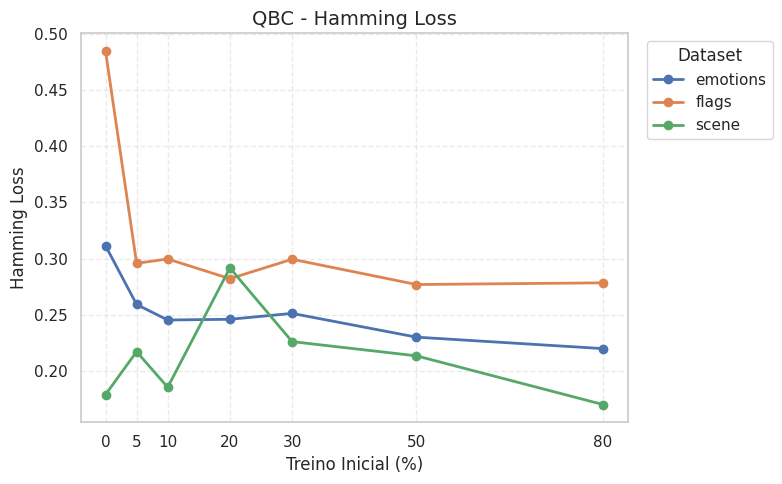

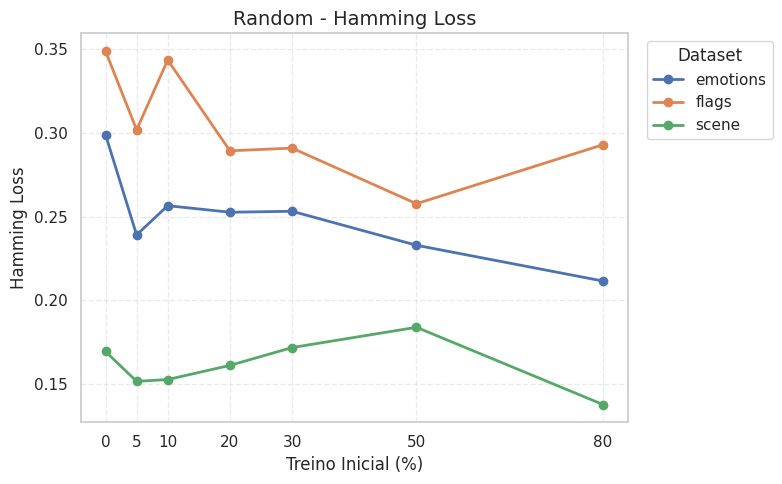

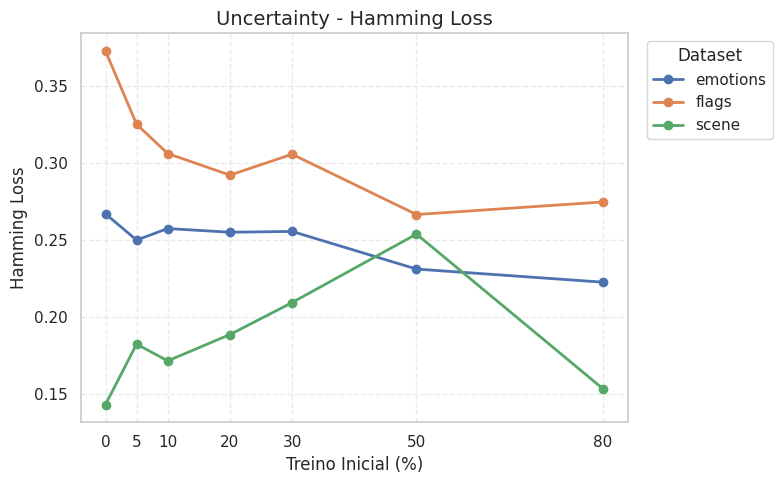

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# CONFIGURAÇÕES
# ==========================

ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "Hamming Loss"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)

# Limpa nomes das colunas
df.columns = df.columns.str.strip()

# Converte o treino inicial para número
df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

# Ordena os dados
df = df.sort_values(["Strategy", "Dataset", "Treino Inicial"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    plt.figure(figsize=(8,5))

    # Uma linha para cada dataset
    for dataset in sorted(dados["Dataset"].unique()):

        aux = dados[dados["Dataset"] == dataset]

        plt.plot(
            aux["Treino Inicial"],
            aux[METRICA],
            marker="o",
            linewidth=2,
            markersize=6,
            label=dataset
        )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(sorted(df["Treino Inicial"].unique()))

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

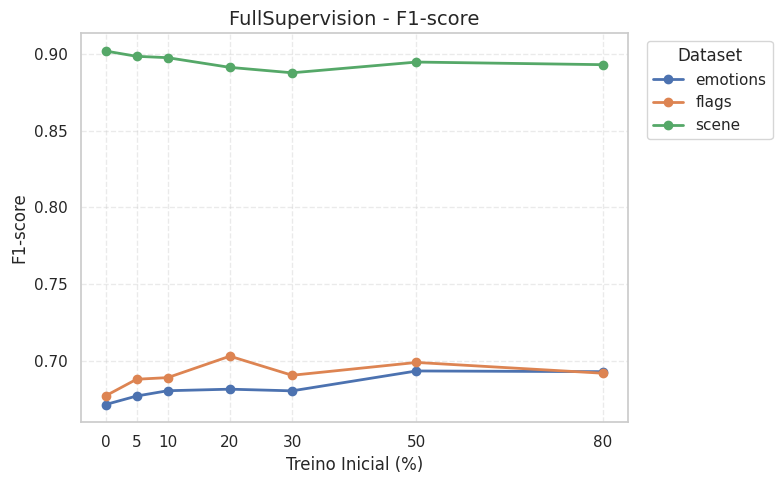

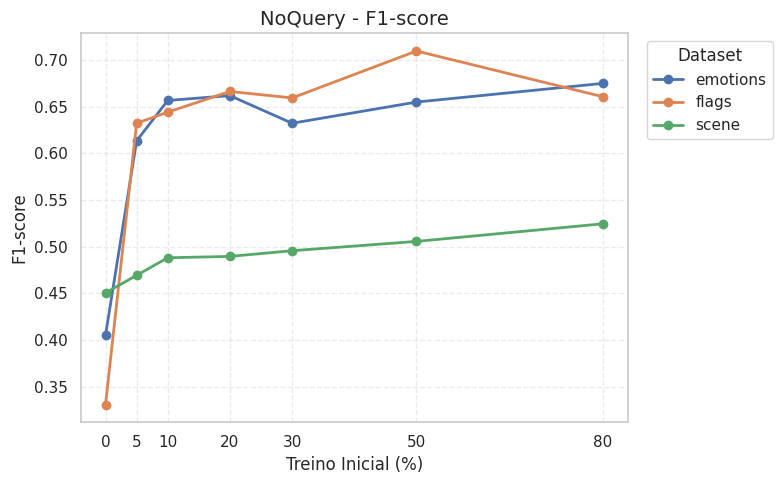

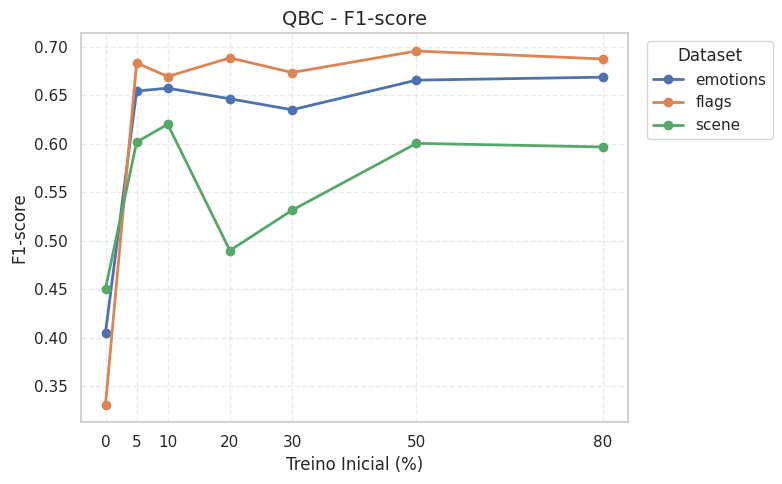

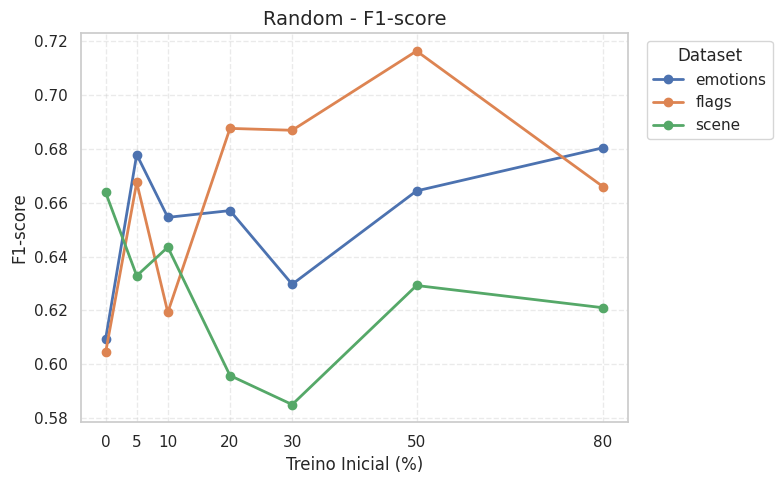

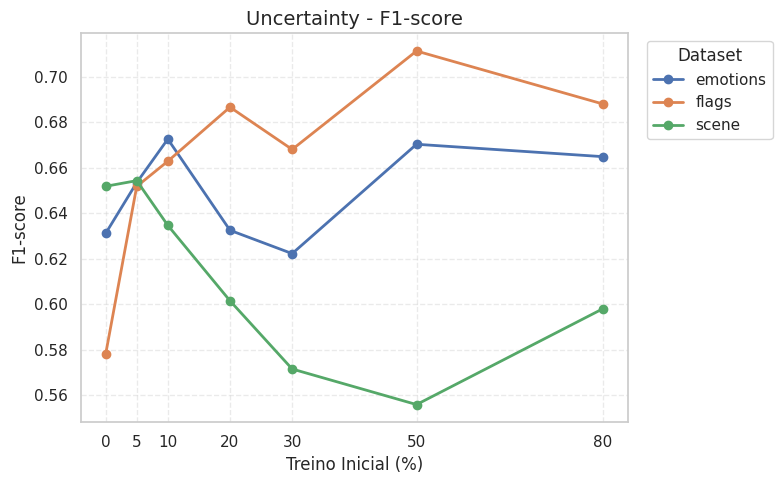

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# CONFIGURAÇÕES
# ==========================

ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "F1-score"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)

# Limpa nomes das colunas
df.columns = df.columns.str.strip()

# Converte o treino inicial para número
df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

# Ordena os dados
df = df.sort_values(["Strategy", "Dataset", "Treino Inicial"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    plt.figure(figsize=(8,5))

    # Uma linha para cada dataset
    for dataset in sorted(dados["Dataset"].unique()):

        aux = dados[dados["Dataset"] == dataset]

        plt.plot(
            aux["Treino Inicial"],
            aux[METRICA],
            marker="o",
            linewidth=2,
            markersize=6,
            label=dataset
        )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(sorted(df["Treino Inicial"].unique()))

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

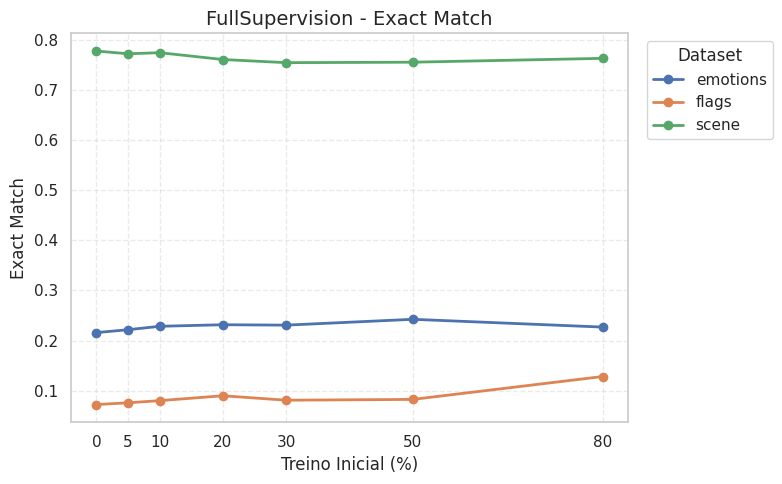

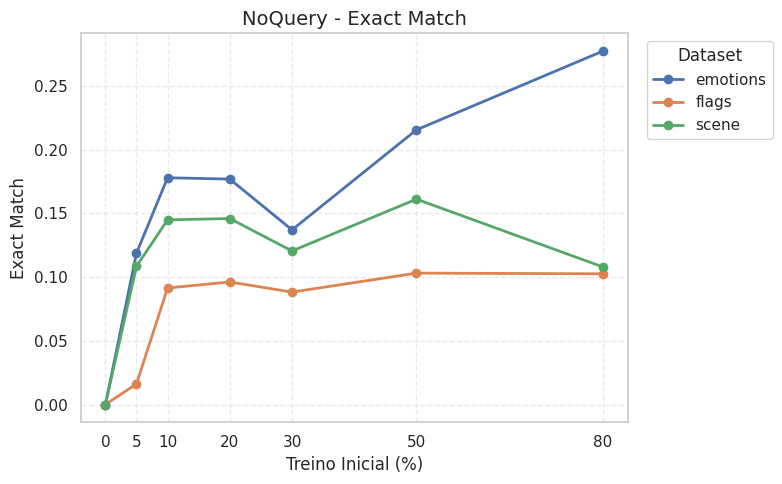

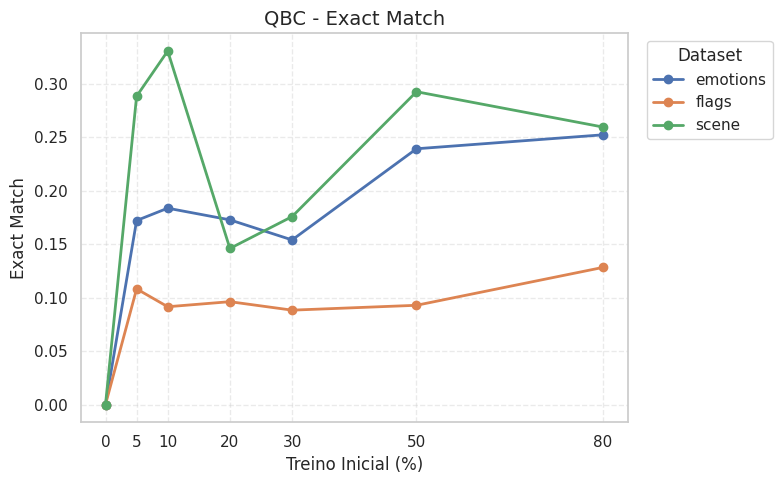

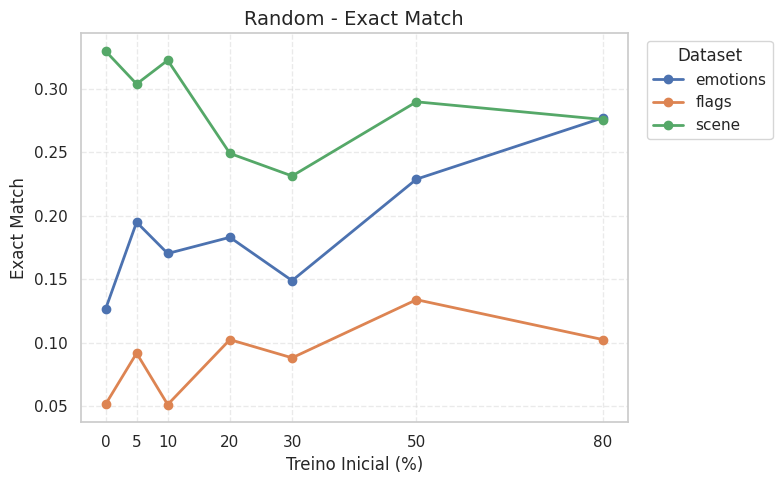

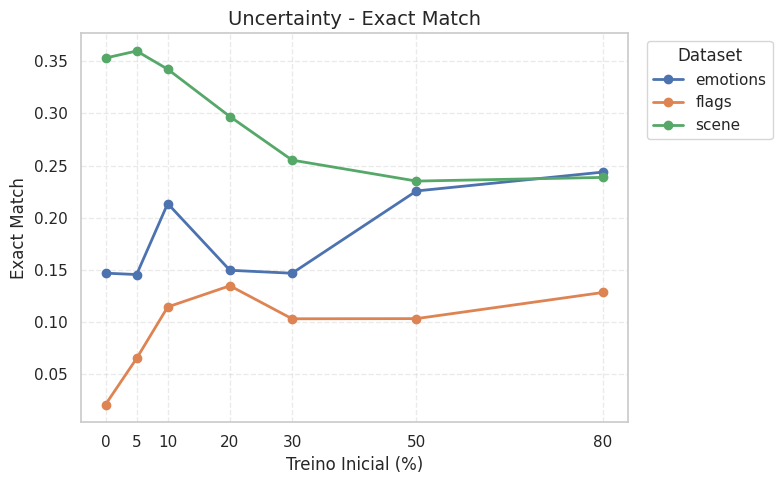

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# CONFIGURAÇÕES
# ==========================

ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "Exact Match"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)

# Limpa nomes das colunas
df.columns = df.columns.str.strip()

# Converte o treino inicial para número
df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

# Ordena os dados
df = df.sort_values(["Strategy", "Dataset", "Treino Inicial"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    plt.figure(figsize=(8,5))

    # Uma linha para cada dataset
    for dataset in sorted(dados["Dataset"].unique()):

        aux = dados[dados["Dataset"] == dataset]

        plt.plot(
            aux["Treino Inicial"],
            aux[METRICA],
            marker="o",
            linewidth=2,
            markersize=6,
            label=dataset
        )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(sorted(df["Treino Inicial"].unique()))

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

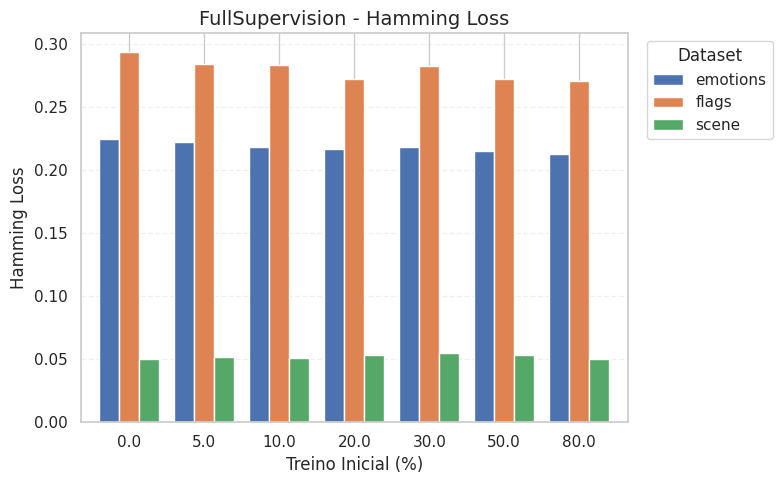

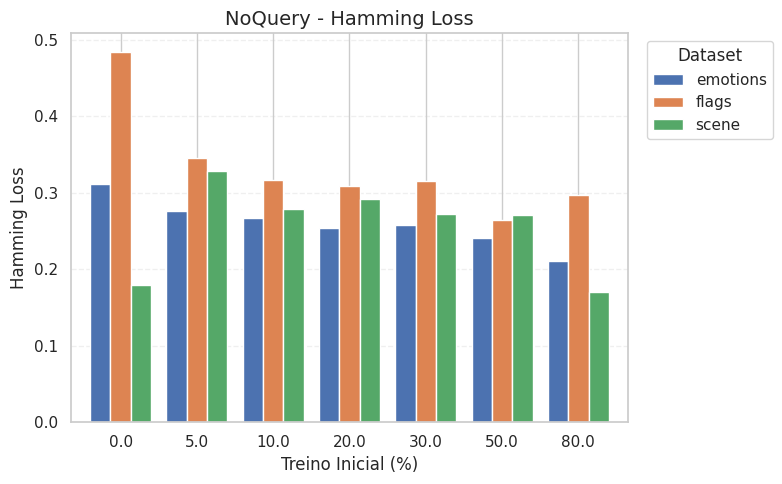

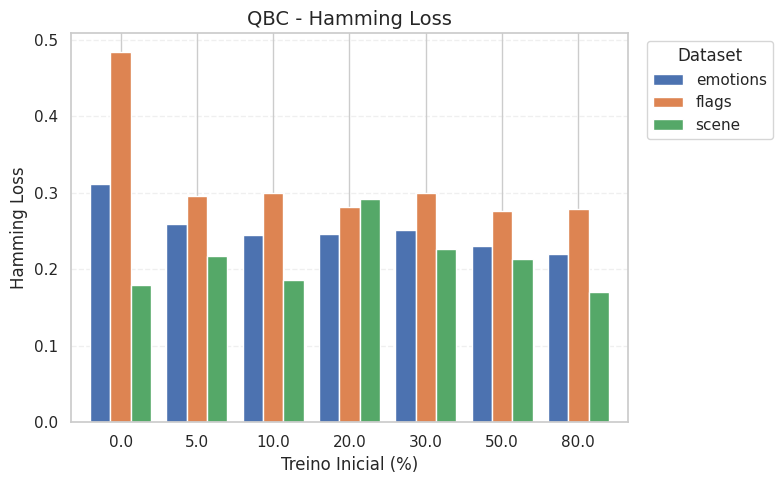

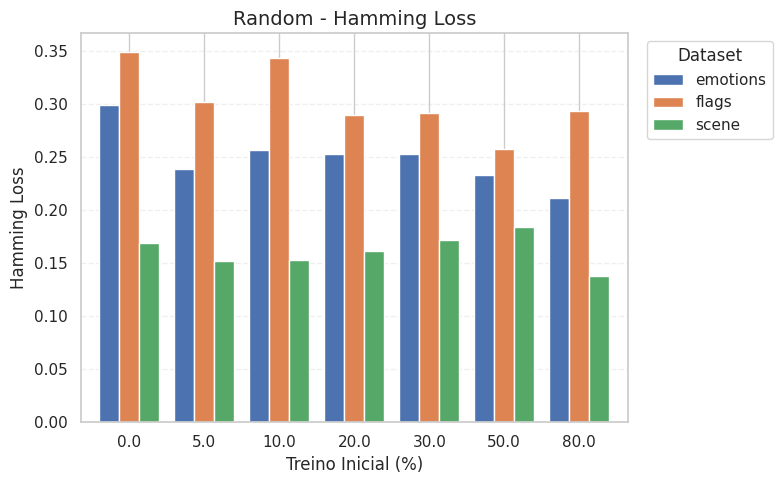

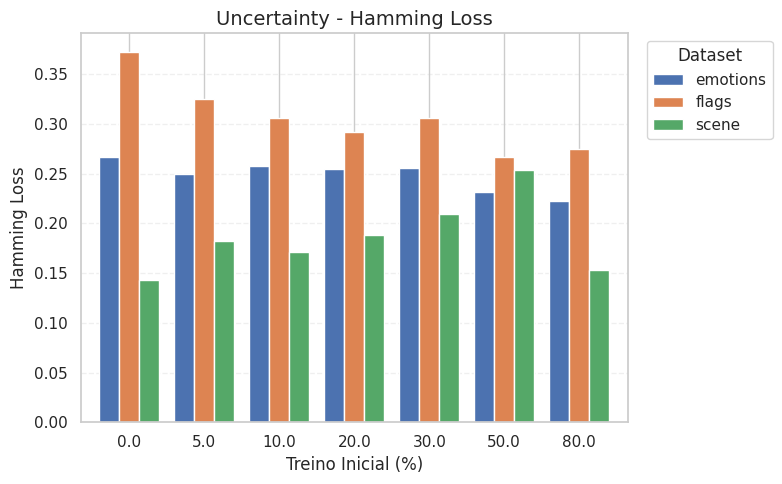

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# CONFIG=========
ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "Hamming Loss"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)
df.columns = df.columns.str.strip()

df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

df = df.sort_values(["Strategy", "Treino Inicial", "Dataset"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    tabela = dados.pivot(
        index="Treino Inicial",
        columns="Dataset",
        values=METRICA
    )

    ax = tabela.plot(
        kind="bar",
        figsize=(8,5),
        width=0.8
    )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(rotation=0)

    plt.grid(axis="y", linestyle="--", alpha=0.3)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}_bar.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

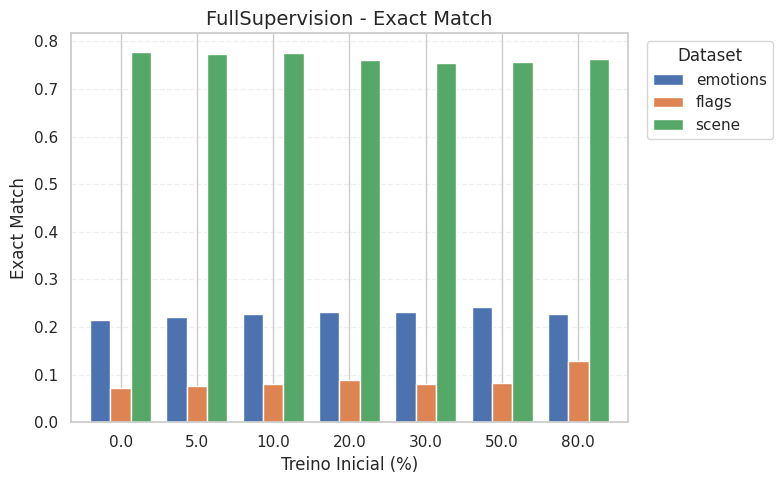

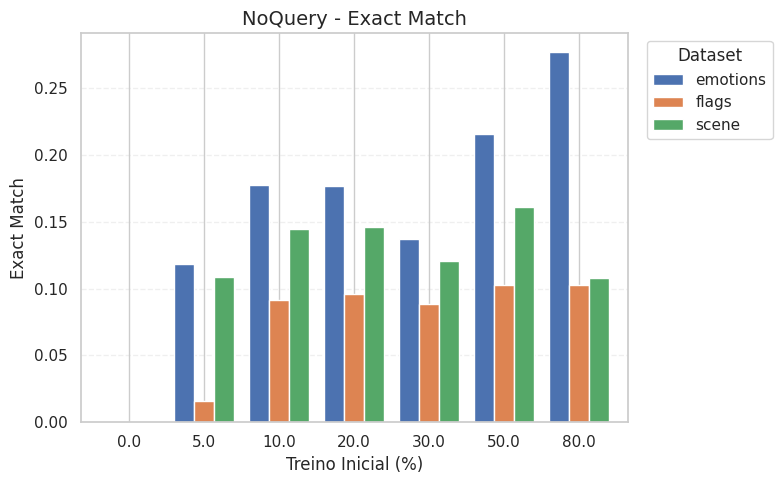

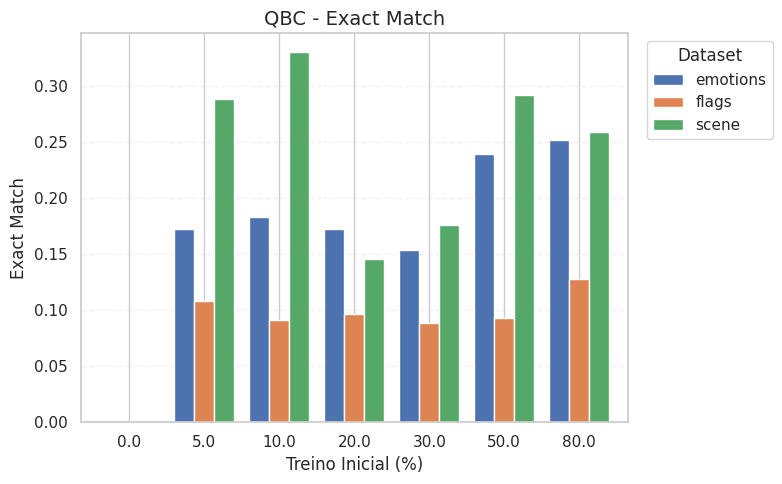

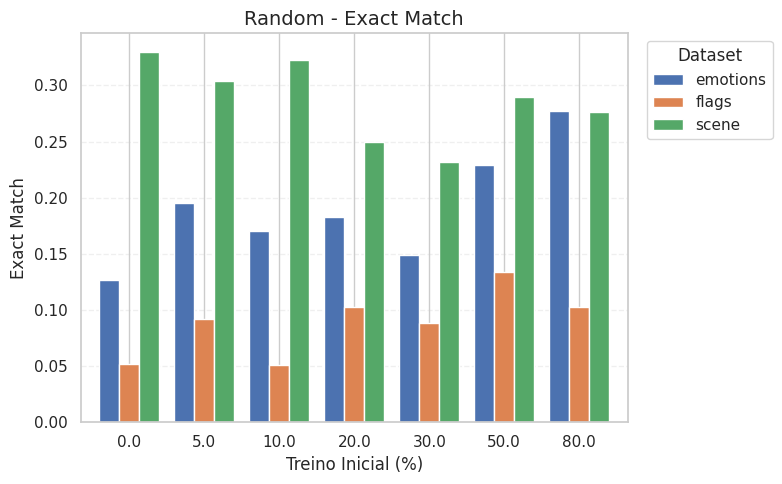

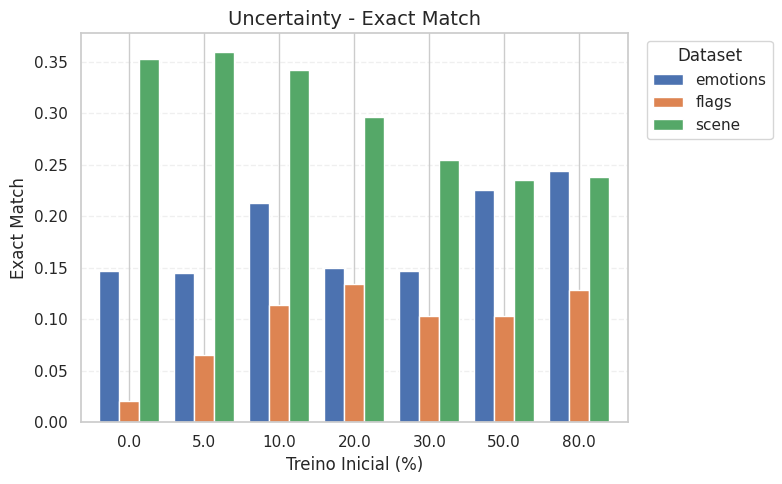

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# CONFIG=========
ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "Exact Match"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)
df.columns = df.columns.str.strip()

df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

df = df.sort_values(["Strategy", "Treino Inicial", "Dataset"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    tabela = dados.pivot(
        index="Treino Inicial",
        columns="Dataset",
        values=METRICA
    )

    ax = tabela.plot(
        kind="bar",
        figsize=(8,5),
        width=0.8
    )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(rotation=0)

    plt.grid(axis="y", linestyle="--", alpha=0.3)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}_bar.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

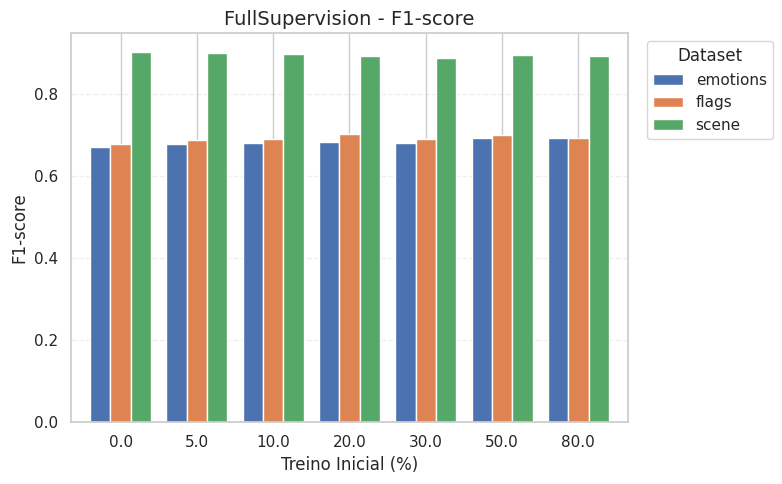

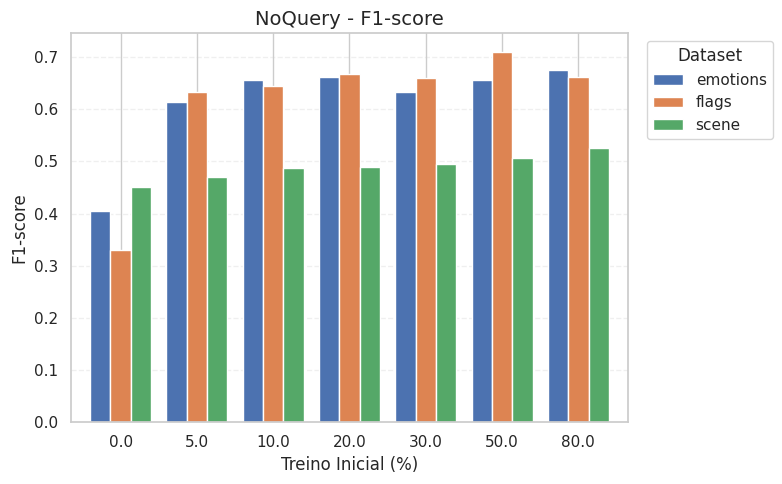

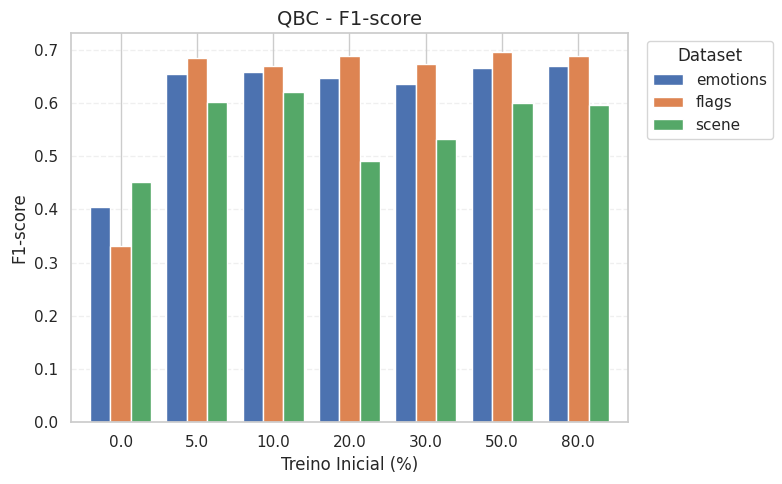

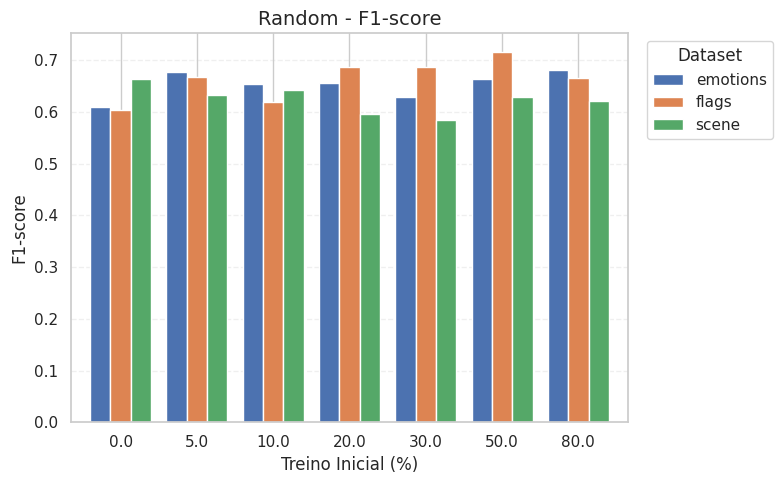

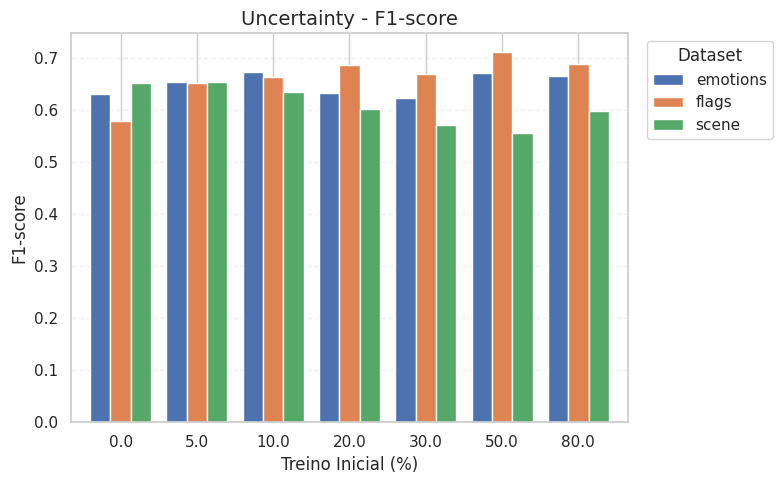

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# CONFIG=========
ARQUIVO = "/content/Resultados-AL-Treino_Inicial-ONLINE - Sheet.csv"
METRICA = "F1-score"

# ==========================

df = pd.read_csv(ARQUIVO, header=1)
df.columns = df.columns.str.strip()

df["Treino Inicial"] = (
    df["Treino Inicial"]
      .astype(str)
      .str.replace("%", "", regex=False)
      .astype(float)
)

df = df.sort_values(["Strategy", "Treino Inicial", "Dataset"])

strategies = sorted(df["Strategy"].unique())

for strategy in strategies:

    dados = df[df["Strategy"] == strategy]

    tabela = dados.pivot(
        index="Treino Inicial",
        columns="Dataset",
        values=METRICA
    )

    ax = tabela.plot(
        kind="bar",
        figsize=(8,5),
        width=0.8
    )

    plt.title(f"{strategy} - {METRICA}", fontsize=14)
    plt.xlabel("Treino Inicial (%)")
    plt.ylabel(METRICA)

    plt.xticks(rotation=0)

    plt.grid(axis="y", linestyle="--", alpha=0.3)

    plt.legend(
        title="Dataset",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{strategy}_{METRICA}_bar.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()